In [1]:
import pandas as pd
import numpy as np


In [ ]:
clinical_patient = pd.read_csv("data_clinical_patient.txt", sep="\t", comment="#", low_memory=False)
clinical_sample = pd.read_csv("data_clinical_sample.txt", sep="\t", comment="#", low_memory=False)


In [4]:
clinical_patient = clinical_patient.rename(columns={"PATIENT_ID": "Patient_ID"})

clinical_patient = clinical_patient[[
    "Patient_ID",
    "CANCER_TYPE",
    "AGE",
    "SEX",
    "RACE",
    "ETHNICITY",
    "HEIGHT_CM",
    "WEIGHT_KG",
    "TUMOR_STAGE",
    "GRADE",
    "PRIMARY_SITE",
    "LATERALITY"
]].drop_duplicates()


KeyError: "['CANCER_TYPE', 'HEIGHT_CM', 'WEIGHT_KG', 'TUMOR_STAGE', 'PRIMARY_SITE', 'LATERALITY'] not in index"

In [7]:
# Robust dataset builder for cBioPortal TCGA-OV (fixed float/endswith issue)
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# ---------- filenames (change only if you renamed files) ----------
CLIN_PAT = "data_clinical_patient.txt"
CLIN_SAMP = "data_clinical_sample.txt"
MRNA = "data_mrna_seq_v2_rsem.txt"
MUT = "data_mutations.txt"        # optional
CNA = "data_cna.txt"             # optional

# ---------- helper utilities ----------
def safe_read(fn):
    if not Path(fn).exists():
        print(f"ERROR: file not found -> {fn}")
        return None
    try:
        df = pd.read_csv(fn, sep="\t", comment="#", low_memory=False)
        print(f"Loaded {fn} -> shape {df.shape}")
        return df
    except Exception as e:
        print(f"Failed to read {fn}: {e}")
        return None

def find_first(colset, options):
    """Return first col in colset that matches any option variant (case-insensitive)."""
    lower_map = {str(c).lower(): c for c in colset}
    for opt in options:
        if opt is None:
            continue
        o = opt.lower()
        if o in lower_map:
            return lower_map[o]
    # try substring matches
    for c in colset:
        cl = str(c).lower()
        for opt in options:
            if opt is None: continue
            if opt.lower() in cl:
                return c
    return None

# ---------- load files ----------
clinical_patient = safe_read(CLIN_PAT)
clinical_sample  = safe_read(CLIN_SAMP)
mrna_df          = safe_read(MRNA)

# stop if essential files missing
if clinical_patient is None or clinical_sample is None or mrna_df is None:
    raise SystemExit("Missing required files. Make sure the three required files are uploaded.")

# ---------- inspect columns (print heads and columns for debug) ----------
print("\n--- clinical_patient columns ---")
print(list(clinical_patient.columns)[:200])
print("\nSample of clinical_patient rows:")
display(clinical_patient.head(3))

print("\n--- clinical_sample columns ---")
print(list(clinical_sample.columns)[:200])
display(clinical_sample.head(3))

print("\n--- mrna columns (first 10 cols) ---")
print(list(mrna_df.columns)[:10])
display(mrna_df.head(2))

# ---------- map clinical columns to standard names ----------
ccols = list(clinical_patient.columns)

mapping_candidates = {
    "patient_id": ["PATIENT_ID", "patient_id", "bcr_patient_barcode", "bcr_patient_barcode_uc", "case_id"],
    "age": ["AGE", "age_at_initial_pathologic_diagnosis", "age"],
    "sex": ["SEX", "sex"],
    "race": ["RACE", "race"],
    "ethnicity": ["ETHNICITY","ethnicity"],
    "tumor_stage": [
        "TUMOR_STAGE", "tumor_stage", "stage", "pathologic_stage",
        "stage_event_pathologic_stage", "ajcc_pathologic_tumor_stage",
        "pathologic_t","pathologic_tumor_stage", "clinical_stage"
    ],
    "grade": ["GRADE", "grade"],
    "primary_site": ["PRIMARY_SITE", "primary_site", "site_of_resection_or_biopsy"],
    "laterality": ["LATERALITY", "laterality"],
    "vital_status": ["VITAL_STATUS", "OS_STATUS", "vital_status"],
    "os_months": ["OS_MONTHS", "overall_survival_months", "os_months", "days_to_death"],
}

mapped = {}
for key, opts in mapping_candidates.items():
    col = find_first(ccols, opts)
    mapped[key] = col
    print(f"Mapped {key:12s} -> {col}")

# Build a cleaned clinical_patient DataFrame with standardized column names
std_clin = pd.DataFrame()
if mapped["patient_id"] is not None:
    std_clin["Patient_ID"] = clinical_patient[mapped["patient_id"]].astype(str)
else:
    std_clin["Patient_ID"] = clinical_patient.iloc[:,0].astype(str)

# fill other fields if present, else NaN
for stdname in ["age", "sex", "race", "ethnicity", "tumor_stage", "grade", "primary_site", "laterality", "vital_status", "os_months"]:
    col = mapped.get(stdname)
    if col is not None:
        std_clin[stdname] = clinical_patient[col]
    else:
        std_clin[stdname] = np.nan

print("\nStandardized clinical_patient sample:")
display(std_clin.head(3))

# ---------- sample map: sample -> patient ----------
scols = list(clinical_sample.columns)
sample_id_col = find_first(scols, ["SAMPLE_ID", "sample_id", "SAMPLE_ID(s)", "SAMPLE", "SAMPLE_BARCODE", "SAMPLE_IDENTIFIER"])
patient_id_col = find_first(scols, ["PATIENT_ID", "patient_id", "bcr_patient_barcode", "patient"])
print(f"\nFound sample_id_col -> {sample_id_col}, patient_id_col -> {patient_id_col}")
if sample_id_col is None or patient_id_col is None:
    print("Clinical_sample doesn't have expected Sample<->Patient mapping columns. Showing columns for manual check:")
    print(scols)
    raise SystemExit("Cannot map sample->patient. Please inspect clinical_sample file.")
sample_map = clinical_sample[[sample_id_col, patient_id_col]].rename(columns={sample_id_col:"Sample_ID", patient_id_col:"Patient_ID"})
sample_map["Sample_ID"] = sample_map["Sample_ID"].astype(str)
sample_map["Patient_ID"] = sample_map["Patient_ID"].astype(str)

print("\nSample map sample:")
display(sample_map.head(3))

# ---------- prepare mrna expression: genes x samples -> samples x genes ----------
mrna_cols = list(mrna_df.columns)
gene_col = mrna_cols[0]  # usually 'Hugo_Symbol' or 'Gene'
print(f"\nAssuming gene column is: {gene_col}")
mrna_long = mrna_df.set_index(gene_col)
mrna_t = mrna_long.T.reset_index().rename(columns={"index":"Sample_ID"})
mrna_t["Sample_ID"] = mrna_t["Sample_ID"].astype(str)

print("Expression matrix (transposed) shape:", mrna_t.shape)
display(mrna_t.iloc[:3, :6])

# ---------- map sample -> patient in expression table ----------
expr_with_patient = mrna_t.merge(sample_map, on="Sample_ID", how="left")
missing_patients = expr_with_patient["Patient_ID"].isna().sum()
print(f"\nAfter direct merge, missing patient IDs for expression samples: {missing_patients}")

if missing_patients > 0:
    expr_with_patient['Patient_ID_tmp'] = expr_with_patient['Sample_ID'].str[:12]
    # drop duplicates in sample_map to allow second join
    smap_unique = sample_map.drop_duplicates(subset=["Patient_ID"])
    expr_with_patient = expr_with_patient.merge(smap_unique, left_on="Patient_ID_tmp", right_on="Patient_ID", how="left", suffixes=("", "_map2"))
    # choose filled Patient_ID from either original or map2
    expr_with_patient["Patient_ID"] = expr_with_patient["Patient_ID"].fillna(expr_with_patient.get("Patient_ID_map2"))
    # safe drop: use str(...) before endswith checks
    cols_to_drop = [c for c in expr_with_patient.columns if str(c).endswith("_map2") or str(c) == "Patient_ID_tmp"]
    expr_with_patient = expr_with_patient.drop(columns=cols_to_drop, errors="ignore")
    missing_patients = expr_with_patient["Patient_ID"].isna().sum()
    print("After trying Patient_ID from first 12 chars, missing patients:", missing_patients)

if expr_with_patient["Patient_ID"].isna().sum() > 0:
    print("Warning: some expression samples couldn't be mapped to patients. They will be dropped.")
expr_with_patient = expr_with_patient.dropna(subset=["Patient_ID"])
expr_with_patient["Patient_ID"] = expr_with_patient["Patient_ID"].astype(str)

# ---------- aggregate expression to patient-level (if multiple samples per patient) ----------
genes = [c for c in expr_with_patient.columns if c not in ("Sample_ID","Patient_ID")]
print(f"Number of gene columns detected: {len(genes)}")

expr_by_patient = expr_with_patient.groupby("Patient_ID")[genes].mean().reset_index()
print("Expression aggregated to patient-level shape:", expr_by_patient.shape)
display(expr_by_patient.head(2).iloc[:, :6])

# ---------- merge clinical + expression ----------
merged = std_clin.merge(expr_by_patient, left_on="Patient_ID", right_on="Patient_ID", how="inner")
print("\nMerged clinical + expression shape:", merged.shape)
display(merged.head(2).iloc[:, :10])

# ---------- normalize / clean stage (target) ----------
if "tumor_stage" in merged.columns:
    stage_col = "tumor_stage"
else:
    print("No 'tumor_stage' column found in merged clinical. Inspect columns: ", merged.columns[:50])
    stage_col = None

def normalize_stage(x):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().replace(" ", "")
    # patterns
    if s.startswith("I") and not s.startswith("II"):
        return "Stage I"
    if s.startswith("II") and not s.startswith("III"):
        return "Stage II"
    if s.startswith("III") and not s.startswith("IV"):
        return "Stage III"
    if s.startswith("IV"):
        return "Stage IV"
    # fallback checks
    if "STAGEI" in s: return "Stage I"
    if "STAGEII" in s: return "Stage II"
    if "STAGEIII" in s: return "Stage III"
    if "STAGEIV" in s: return "Stage IV"
    return np.nan

if stage_col:
    merged["Clean_Stage"] = merged[stage_col].apply(normalize_stage)
else:
    merged["Clean_Stage"] = np.nan

print("\nStage value counts (raw -> cleaned):")
if stage_col:
    print(merged[stage_col].value_counts(dropna=False).head(20))
print(merged["Clean_Stage"].value_counts(dropna=False))

# drop rows without Clean_Stage
before = merged.shape[0]
merged = merged.dropna(subset=["Clean_Stage"])
after = merged.shape[0]
print(f"Dropped {before-after} patients because of missing stage. Remaining: {after}")

# ---------- final cleaning: drop columns with >50% missing and fill rest with 0 for expression, keep clinical intact ----------
thresh = 0.5 * merged.shape[0]
merged = merged.loc[:, merged.isna().sum() < thresh]   # drop columns with too many NaNs
clinical_keep = ["Patient_ID","age","sex","race","ethnicity","tumor_stage","grade","primary_site","laterality","vital_status","os_months","Clean_Stage"]
expr_cols = [c for c in merged.columns if c not in clinical_keep]
merged[expr_cols] = merged[expr_cols].fillna(0)

# ---------- save ----------
outfn = "TCGA_OV_cBioportal_merged_fixed.csv"
merged.to_csv(outfn, index=False)
print("\nSaved final dataset to:", outfn)
print("Final shape:", merged.shape)


Loaded data_clinical_patient.txt -> shape (587, 53)
Loaded data_clinical_sample.txt -> shape (617, 29)
Loaded data_mrna_seq_v2_rsem.txt -> shape (20531, 309)

--- clinical_patient columns ---
['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY', 'HISTORY_NEOADJUVANT_TRTYN', 'INITIAL_PATHOLOGIC_DX_YEAR', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'TUMOR_STATUS', 'GRADE', 'RESIDUAL_TUMOR', 'VASCULAR_INVASION_INDICATOR', 'LYMPHOVASCULAR_INVASION_INDICATOR', 'KARNOFSKY_PERFORMANCE_SCORE', 'ECOG_SCORE', 'PERFORMANCE_STATUS_TIMING', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT', 'TREATMENT_OUTCOME_FIRST_COURSE', 'DAYS_TO_TUMOR_PROGRESSION', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'AGE', 'CLIN_M_STAGE', 'CLIN_N_STAGE', 'CLIN_T_STAGE', 'CLINICAL_STAGE', 'DAYS_TO_INITIAL_PATHOLOGIC_DI

,OTHER_PATIENT_ID,PATIENT_ID,FORM_COMPLETION_DATE,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX,RACE,ETHNICITY,JEWISH_RELIGION_HERITAGE_INDICATOR,HISTORY_OTHER_MALIGNANCY,HISTORY_NEOADJUVANT_TRTYN,INITIAL_PATHOLOGIC_DX_YEAR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER,TUMOR_STATUS,GRADE,RESIDUAL_TUMOR,VASCULAR_INVASION_INDICATOR,LYMPHOVASCULAR_INVASION_INDICATOR,KARNOFSKY_PERFORMANCE_SCORE,ECOG_SCORE,PERFORMANCE_STATUS_TIMING,RADIATION_TREATMENT_ADJUVANT,PHARMACEUTICAL_TX_ADJUVANT,TREATMENT_OUTCOME_FIRST_COURSE,DAYS_TO_TUMOR_PROGRESSION,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,AGE,CLIN_M_STAGE,CLIN_N_STAGE,CLIN_T_STAGE,CLINICAL_STAGE,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DAYS_TO_PATIENT_PROGRESSION_FREE,DISEASE_CODE,EXTRANODAL_INVOLVEMENT,HISTOLOGICAL_DIAGNOSIS,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,AJCC_PATHOLOGIC_TUMOR_STAGE,PROJECT_CODE,STAGE_OTHER,AJCC_STAGING_EDITION,TISSUE_SOURCE_SITE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS
0,6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,3/26/09,[Not Available],[Not Available],Female,WHITE,NOT HISPANIC OR LATINO,[Not Available],[Not Available],No,2004,Tumor resection,[Not Applicable],WITH TUMOR,G3,[Not Available],NO,YES,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],78,[Not Applicable],[Not Applicable],[Not Applicable],Stage IIIC,0,[Not Available],[Not Available],[Not Applicable],Serous Cystadenocarcinoma,C56.9,8441/3,C56.9,YES,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],[Not Available],[Not Available],[Not Available],4,1:DECEASED,43.89,1:Recurred/Progressed,15.08
1,b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,3/26/09,[Not Available],[Not Available],Female,WHITE,NOT HISPANIC OR LATINO,[Not Available],[Not Available],No,2002,Tumor resection,[Not Applicable],WITH TUMOR,G3,[Not Available],[Not Available],NO,[Not Available],1,Preoperative,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],70,[Not Applicable],[Not Applicable],[Not Applicable],Stage IIIC,0,[Not Available],[Not Available],[Not Applicable],Serous Cystadenocarcinoma,C56.9,8441/3,C56.9,YES,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],[Not Available],[Not Available],[Not Available],4,1:DECEASED,40.97,1:Recurred/Progressed,12.91
2,ab3dbbbe-eed6-4a35-a505-1815225e86c9,TCGA-04-1335,3/26/09,[Not Available],[Not Available],Female,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],[Not Available],No,2005,Tumor resection,[Not Applicable],WITH TUMOR,G2,[Not Available],NO,NO,[Not Available],[Not Available],Preoperative,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],60,[Not Applicable],[Not Applicable],[Not Applicable],Stage IB,0,[Not Available],[Not Available],[Not Applicable],Serous Cystadenocarcinoma,C56.9,8441/3,C56.9,YES,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],[Not Available],[Not Available],[Not Available],4,1:DECEASED,1.81,[Not Available],[Not Available]



--- clinical_sample columns ---
['PATIENT_ID', 'SAMPLE_ID', 'OTHER_SAMPLE_ID', 'SPECIMEN_CURRENT_WEIGHT', 'DAYS_TO_COLLECTION', 'DAYS_TO_SPECIMEN_COLLECTION', 'SPECIMEN_FREEZING_METHOD', 'SAMPLE_INITIAL_WEIGHT', 'SPECIMEN_SECOND_LONGEST_DIMENSION', 'IS_FFPE', 'LONGEST_DIMENSION', 'METHOD_OF_SAMPLE_PROCUREMENT', 'OCT_EMBEDDED', 'OTHER_METHOD_OF_SAMPLE_PROCUREMENT', 'PATHOLOGY_REPORT_FILE_NAME', 'PATHOLOGY_REPORT_UUID', 'SAMPLE_TYPE', 'SAMPLE_TYPE_ID', 'SHORTEST_DIMENSION', 'TIME_BETWEEN_CLAMPING_AND_FREEZING', 'TIME_BETWEEN_EXCISION_AND_FREEZING', 'VIAL_NUMBER', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'PRIMARY_SITE', 'TUMOR_TISSUE_SITE', 'SOMATIC_STATUS', 'TMB_NONSYNONYMOUS']


,PATIENT_ID,SAMPLE_ID,OTHER_SAMPLE_ID,SPECIMEN_CURRENT_WEIGHT,DAYS_TO_COLLECTION,DAYS_TO_SPECIMEN_COLLECTION,SPECIMEN_FREEZING_METHOD,SAMPLE_INITIAL_WEIGHT,SPECIMEN_SECOND_LONGEST_DIMENSION,IS_FFPE,LONGEST_DIMENSION,METHOD_OF_SAMPLE_PROCUREMENT,OCT_EMBEDDED,OTHER_METHOD_OF_SAMPLE_PROCUREMENT,PATHOLOGY_REPORT_FILE_NAME,PATHOLOGY_REPORT_UUID,SAMPLE_TYPE,SAMPLE_TYPE_ID,SHORTEST_DIMENSION,TIME_BETWEEN_CLAMPING_AND_FREEZING,TIME_BETWEEN_EXCISION_AND_FREEZING,VIAL_NUMBER,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,PRIMARY_SITE,TUMOR_TISSUE_SITE,SOMATIC_STATUS,TMB_NONSYNONYMOUS
0,TCGA-10-0926,TCGA-10-0926-01,1c7e0067-e266-4967-9322-5967e112888e,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],0.8,NO,1,[Not Available],[Not Available],[Not Available],TCGA-10-0926.b940b1b3-8278-400e-b43a-e7897e036...,b940b1b3-8278-400e-b43a-e7897e0361b7,Primary,1,0.6,[Not Available],[Not Available],A,SOC,Ovarian Cancer,Serous Ovarian Cancer,Bilateral,Ovary,Matched,1.133333
1,TCGA-10-0927,TCGA-10-0927-01,97efbf70-83ef-49aa-ac3a-f0d0067a2a10,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],0.7,NO,1.1,[Not Available],[Not Available],[Not Available],TCGA-10-0927.3d93f935-2a93-4987-99c6-0b75e2e59...,3d93f935-2a93-4987-99c6-0b75e2e59cd3,Primary,1,0.6,[Not Available],[Not Available],A,SOC,Ovarian Cancer,Serous Ovarian Cancer,Bilateral,Ovary,Matched,0.700000
2,TCGA-10-0928,TCGA-10-0928-01,4416312b-c64f-4fb2-9819-6ccf9b8ab219,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],0.8,NO,1,[Not Available],[Not Available],[Not Available],TCGA-10-0928.859b2662-493a-4ead-9ac7-0aa8d0a7a...,859b2662-493a-4ead-9ac7-0aa8d0a7a3d8,Primary,1,0.4,[Not Available],[Not Available],A,SOC,Ovarian Cancer,Serous Ovarian Cancer,Bilateral,Ovary,Matched,1.100000



--- mrna columns (first 10 cols) ---
['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-04-1348-01', 'TCGA-04-1357-01', 'TCGA-04-1362-01', 'TCGA-04-1364-01', 'TCGA-04-1365-01', 'TCGA-04-1514-01', 'TCGA-04-1519-01', 'TCGA-09-0364-01']


...


After direct merge, missing patient IDs for expression samples: 1
After trying Patient_ID from first 12 chars, missing patients: 1
Number of gene columns detected: 20531
Expression aggregated to patient-level shape: (304, 20566)


,Patient_ID,LOC100130426,UBE2Q2P3,UBE2Q2P3,UBE2Q2P3,UBE2Q2P3
0,TCGA-04-1348,0.0,27.3245,45.8134,27.3245,45.8134
1,TCGA-04-1357,0.0,21.9661,36.6276,21.9661,36.6276



Merged clinical + expression shape: (304, 20576)


,Patient_ID,age,sex,race,ethnicity,tumor_stage,grade,primary_site,laterality,vital_status
0,TCGA-04-1348,44,Female,WHITE,HISPANIC OR LATINO,[Not Applicable],G3,NaN,NaN,1:DECEASED
1,TCGA-04-1357,52,Female,[Not Available],[Not Available],[Not Applicable],G3,NaN,NaN,0:LIVING



Stage value counts (raw -> cleaned):
tumor_stage
[Not Applicable]    304
Name: count, dtype: int64
Clean_Stage
NaN    304
Name: count, dtype: int64
Dropped 304 patients because of missing stage. Remaining: 0

Saved final dataset to: TCGA_OV_cBioportal_merged_fixed.csv
Final shape: (0, 0)


In [8]:
# Robust dataset builder for cBioPortal TCGA-OV (fixed float/endswith issue)
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# ---------- filenames (change only if you renamed files) ----------
CLIN_PAT = "data_clinical_patient.txt"
CLIN_SAMP = "data_clinical_sample.txt"
MRNA = "data_mrna_seq_v2_rsem.txt"
MUT = "data_mutations.txt"        # optional
CNA = "data_cna.txt"             # optional

# ---------- helper utilities ----------
def safe_read(fn):
    if not Path(fn).exists():
        print(f"ERROR: file not found -> {fn}")
        return None
    try:
        df = pd.read_csv(fn, sep="\t", comment="#", low_memory=False)
        print(f"Loaded {fn} -> shape {df.shape}")
        return df
    except Exception as e:
        print(f"Failed to read {fn}: {e}")
        return None

def find_first(colset, options):
    """Return first col in colset that matches any option variant (case-insensitive)."""
    lower_map = {str(c).lower(): c for c in colset}
    for opt in options:
        if opt is None:
            continue
        o = opt.lower()
        if o in lower_map:
            return lower_map[o]
    # try substring matches
    for c in colset:
        cl = str(c).lower()
        for opt in options:
            if opt is None: continue
            if opt.lower() in cl:
                return c
    return None

# ---------- load files ----------
clinical_patient = safe_read(CLIN_PAT)
clinical_sample  = safe_read(CLIN_SAMP)
mrna_df          = safe_read(MRNA)

# stop if essential files missing
if clinical_patient is None or clinical_sample is None or mrna_df is None:
    raise SystemExit("Missing required files. Make sure the three required files are uploaded.")

# ---------- inspect columns (print heads and columns for debug) ----------
print("\n--- clinical_patient columns ---")
print(list(clinical_patient.columns)[:200])
print("\nSample of clinical_patient rows:")
display(clinical_patient.head(3))

print("\n--- clinical_sample columns ---")
print(list(clinical_sample.columns)[:200])
display(clinical_sample.head(3))

print("\n--- mrna columns (first 10 cols) ---")
print(list(mrna_df.columns)[:10])
display(mrna_df.head(2))

# ---------- map clinical columns to standard names ----------
ccols = list(clinical_patient.columns)

mapping_candidates = {
    "patient_id": ["PATIENT_ID", "patient_id", "bcr_patient_barcode", "bcr_patient_barcode_uc", "case_id"],
    "age": ["AGE", "age_at_initial_pathologic_diagnosis", "age"],
    "sex": ["SEX", "sex"],
    "race": ["RACE", "race"],
    "ethnicity": ["ETHNICITY","ethnicity"],
    "tumor_stage": [
        "TUMOR_STAGE", "tumor_stage", "stage", "pathologic_stage",
        "stage_event_pathologic_stage", "ajcc_pathologic_tumor_stage",
        "pathologic_t","pathologic_tumor_stage", "clinical_stage"
    ],
    "grade": ["GRADE", "grade"],
    "primary_site": ["PRIMARY_SITE", "primary_site", "site_of_resection_or_biopsy"],
    "laterality": ["LATERALITY", "laterality"],
    "vital_status": ["VITAL_STATUS", "OS_STATUS", "vital_status"],
    "os_months": ["OS_MONTHS", "overall_survival_months", "os_months", "days_to_death"],
}

mapped = {}
for key, opts in mapping_candidates.items():
    col = find_first(ccols, opts)
    mapped[key] = col
    print(f"Mapped {key:12s} -> {col}")

# Build a cleaned clinical_patient DataFrame with standardized column names
std_clin = pd.DataFrame()
if mapped["patient_id"] is not None:
    std_clin["Patient_ID"] = clinical_patient[mapped["patient_id"]].astype(str)
else:
    std_clin["Patient_ID"] = clinical_patient.iloc[:,0].astype(str)

# fill other fields if present, else NaN
for stdname in ["age", "sex", "race", "ethnicity", "tumor_stage", "grade", "primary_site", "laterality", "vital_status", "os_months"]:
    col = mapped.get(stdname)
    if col is not None:
        std_clin[stdname] = clinical_patient[col]
    else:
        std_clin[stdname] = np.nan

print("\nStandardized clinical_patient sample:")
display(std_clin.head(3))

# ---------- sample map: sample -> patient ----------
scols = list(clinical_sample.columns)
sample_id_col = find_first(scols, ["SAMPLE_ID", "sample_id", "SAMPLE_ID(s)", "SAMPLE", "SAMPLE_BARCODE", "SAMPLE_IDENTIFIER"])
patient_id_col = find_first(scols, ["PATIENT_ID", "patient_id", "bcr_patient_barcode", "patient"])
print(f"\nFound sample_id_col -> {sample_id_col}, patient_id_col -> {patient_id_col}")
if sample_id_col is None or patient_id_col is None:
    print("Clinical_sample doesn't have expected Sample<->Patient mapping columns. Showing columns for manual check:")
    print(scols)
    raise SystemExit("Cannot map sample->patient. Please inspect clinical_sample file.")
sample_map = clinical_sample[[sample_id_col, patient_id_col]].rename(columns={sample_id_col:"Sample_ID", patient_id_col:"Patient_ID"})
sample_map["Sample_ID"] = sample_map["Sample_ID"].astype(str)
sample_map["Patient_ID"] = sample_map["Patient_ID"].astype(str)

print("\nSample map sample:")
display(sample_map.head(3))

# ---------- prepare mrna expression: genes x samples -> samples x genes ----------
mrna_cols = list(mrna_df.columns)
gene_col = mrna_cols[0]  # usually 'Hugo_Symbol' or 'Gene'
print(f"\nAssuming gene column is: {gene_col}")
mrna_long = mrna_df.set_index(gene_col)
mrna_t = mrna_long.T.reset_index().rename(columns={"index":"Sample_ID"})
mrna_t["Sample_ID"] = mrna_t["Sample_ID"].astype(str)

print("Expression matrix (transposed) shape:", mrna_t.shape)
display(mrna_t.iloc[:3, :6])

# ---------- map sample -> patient in expression table ----------
expr_with_patient = mrna_t.merge(sample_map, on="Sample_ID", how="left")
missing_patients = expr_with_patient["Patient_ID"].isna().sum()
print(f"\nAfter direct merge, missing patient IDs for expression samples: {missing_patients}")

if missing_patients > 0:
    expr_with_patient['Patient_ID_tmp'] = expr_with_patient['Sample_ID'].str[:12]
    # drop duplicates in sample_map to allow second join
    smap_unique = sample_map.drop_duplicates(subset=["Patient_ID"])
    expr_with_patient = expr_with_patient.merge(smap_unique, left_on="Patient_ID_tmp", right_on="Patient_ID", how="left", suffixes=("", "_map2"))
    # choose filled Patient_ID from either original or map2
    expr_with_patient["Patient_ID"] = expr_with_patient["Patient_ID"].fillna(expr_with_patient.get("Patient_ID_map2"))
    # safe drop: use str(...) before endswith checks
    cols_to_drop = [c for c in expr_with_patient.columns if str(c).endswith("_map2") or str(c) == "Patient_ID_tmp"]
    expr_with_patient = expr_with_patient.drop(columns=cols_to_drop, errors="ignore")
    missing_patients = expr_with_patient["Patient_ID"].isna().sum()
    print("After trying Patient_ID from first 12 chars, missing patients:", missing_patients)

if expr_with_patient["Patient_ID"].isna().sum() > 0:
    print("Warning: some expression samples couldn't be mapped to patients. They will be dropped.")
expr_with_patient = expr_with_patient.dropna(subset=["Patient_ID"])
expr_with_patient["Patient_ID"] = expr_with_patient["Patient_ID"].astype(str)

# ---------- aggregate expression to patient-level (if multiple samples per patient) ----------
genes = [c for c in expr_with_patient.columns if c not in ("Sample_ID","Patient_ID")]
print(f"Number of gene columns detected: {len(genes)}")

expr_by_patient = expr_with_patient.groupby("Patient_ID")[genes].mean().reset_index()
print("Expression aggregated to patient-level shape:", expr_by_patient.shape)
display(expr_by_patient.head(2).iloc[:, :6])

# ---------- merge clinical + expression ----------
merged = std_clin.merge(expr_by_patient, left_on="Patient_ID", right_on="Patient_ID", how="inner")
print("\nMerged clinical + expression shape:", merged.shape)
display(merged.head(2).iloc[:, :10])

# ---------- normalize / clean stage (target) ----------
if "tumor_stage" in merged.columns:
    stage_col = "tumor_stage"
else:
    print("No 'tumor_stage' column found in merged clinical. Inspect columns: ", merged.columns[:50])
    stage_col = None

def normalize_stage(x):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().replace(" ", "")
    # patterns
    if s.startswith("I") and not s.startswith("II"):
        return "Stage I"
    if s.startswith("II") and not s.startswith("III"):
        return "Stage II"
    if s.startswith("III") and not s.startswith("IV"):
        return "Stage III"
    if s.startswith("IV"):
        return "Stage IV"
    # fallback checks
    if "STAGEI" in s: return "Stage I"
    if "STAGEII" in s: return "Stage II"
    if "STAGEIII" in s: return "Stage III"
    if "STAGEIV" in s: return "Stage IV"
    return np.nan

if stage_col:
    merged["Clean_Stage"] = merged[stage_col].apply(normalize_stage)
else:
    merged["Clean_Stage"] = np.nan

print("\nStage value counts (raw -> cleaned):")
if stage_col:
    print(merged[stage_col].value_counts(dropna=False).head(20))
print(merged["Clean_Stage"].value_counts(dropna=False))

# drop rows without Clean_Stage
before = merged.shape[0]
merged = merged.dropna(subset=["Clean_Stage"])
after = merged.shape[0]
print(f"Dropped {before-after} patients because of missing stage. Remaining: {after}")

# ---------- final cleaning: drop columns with >50% missing and fill rest with 0 for expression, keep clinical intact ----------
thresh = 0.5 * merged.shape[0]
merged = merged.loc[:, merged.isna().sum() < thresh]   # drop columns with too many NaNs
clinical_keep = ["Patient_ID","age","sex","race","ethnicity","tumor_stage","grade","primary_site","laterality","vital_status","os_months","Clean_Stage"]
expr_cols = [c for c in merged.columns if c not in clinical_keep]
merged[expr_cols] = merged[expr_cols].fillna(0)

# ---------- save ----------
outfn = "TCGA_OV_cBioportal_merged_fixed.csv"
merged.to_csv(outfn, index=False)
print("\nSaved final dataset to:", outfn)
print("Final shape:", merged.shape)


Loaded data_clinical_patient.txt -> shape (587, 53)
Loaded data_clinical_sample.txt -> shape (617, 29)
Loaded data_mrna_seq_v2_rsem.txt -> shape (20531, 309)

--- clinical_patient columns ---
['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY', 'HISTORY_NEOADJUVANT_TRTYN', 'INITIAL_PATHOLOGIC_DX_YEAR', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'TUMOR_STATUS', 'GRADE', 'RESIDUAL_TUMOR', 'VASCULAR_INVASION_INDICATOR', 'LYMPHOVASCULAR_INVASION_INDICATOR', 'KARNOFSKY_PERFORMANCE_SCORE', 'ECOG_SCORE', 'PERFORMANCE_STATUS_TIMING', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT', 'TREATMENT_OUTCOME_FIRST_COURSE', 'DAYS_TO_TUMOR_PROGRESSION', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'AGE', 'CLIN_M_STAGE', 'CLIN_N_STAGE', 'CLIN_T_STAGE', 'CLINICAL_STAGE', 'DAYS_TO_INITIAL_PATHOLOGIC_DI

,OTHER_PATIENT_ID,PATIENT_ID,FORM_COMPLETION_DATE,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX,RACE,ETHNICITY,JEWISH_RELIGION_HERITAGE_INDICATOR,HISTORY_OTHER_MALIGNANCY,HISTORY_NEOADJUVANT_TRTYN,INITIAL_PATHOLOGIC_DX_YEAR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER,TUMOR_STATUS,GRADE,RESIDUAL_TUMOR,VASCULAR_INVASION_INDICATOR,LYMPHOVASCULAR_INVASION_INDICATOR,KARNOFSKY_PERFORMANCE_SCORE,ECOG_SCORE,PERFORMANCE_STATUS_TIMING,RADIATION_TREATMENT_ADJUVANT,PHARMACEUTICAL_TX_ADJUVANT,TREATMENT_OUTCOME_FIRST_COURSE,DAYS_TO_TUMOR_PROGRESSION,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,AGE,CLIN_M_STAGE,CLIN_N_STAGE,CLIN_T_STAGE,CLINICAL_STAGE,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DAYS_TO_PATIENT_PROGRESSION_FREE,DISEASE_CODE,EXTRANODAL_INVOLVEMENT,HISTOLOGICAL_DIAGNOSIS,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,AJCC_PATHOLOGIC_TUMOR_STAGE,PROJECT_CODE,STAGE_OTHER,AJCC_STAGING_EDITION,TISSUE_SOURCE_SITE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS
0,6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,3/26/09,[Not Available],[Not Available],Female,WHITE,NOT HISPANIC OR LATINO,[Not Available],[Not Available],No,2004,Tumor resection,[Not Applicable],WITH TUMOR,G3,[Not Available],NO,YES,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],78,[Not Applicable],[Not Applicable],[Not Applicable],Stage IIIC,0,[Not Available],[Not Available],[Not Applicable],Serous Cystadenocarcinoma,C56.9,8441/3,C56.9,YES,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],[Not Available],[Not Available],[Not Available],4,1:DECEASED,43.89,1:Recurred/Progressed,15.08
1,b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,3/26/09,[Not Available],[Not Available],Female,WHITE,NOT HISPANIC OR LATINO,[Not Available],[Not Available],No,2002,Tumor resection,[Not Applicable],WITH TUMOR,G3,[Not Available],[Not Available],NO,[Not Available],1,Preoperative,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],70,[Not Applicable],[Not Applicable],[Not Applicable],Stage IIIC,0,[Not Available],[Not Available],[Not Applicable],Serous Cystadenocarcinoma,C56.9,8441/3,C56.9,YES,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],[Not Available],[Not Available],[Not Available],4,1:DECEASED,40.97,1:Recurred/Progressed,12.91
2,ab3dbbbe-eed6-4a35-a505-1815225e86c9,TCGA-04-1335,3/26/09,[Not Available],[Not Available],Female,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],[Not Available],No,2005,Tumor resection,[Not Applicable],WITH TUMOR,G2,[Not Available],NO,NO,[Not Available],[Not Available],Preoperative,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],60,[Not Applicable],[Not Applicable],[Not Applicable],Stage IB,0,[Not Available],[Not Available],[Not Applicable],Serous Cystadenocarcinoma,C56.9,8441/3,C56.9,YES,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],[Not Available],[Not Available],[Not Available],4,1:DECEASED,1.81,[Not Available],[Not Available]



--- clinical_sample columns ---
['PATIENT_ID', 'SAMPLE_ID', 'OTHER_SAMPLE_ID', 'SPECIMEN_CURRENT_WEIGHT', 'DAYS_TO_COLLECTION', 'DAYS_TO_SPECIMEN_COLLECTION', 'SPECIMEN_FREEZING_METHOD', 'SAMPLE_INITIAL_WEIGHT', 'SPECIMEN_SECOND_LONGEST_DIMENSION', 'IS_FFPE', 'LONGEST_DIMENSION', 'METHOD_OF_SAMPLE_PROCUREMENT', 'OCT_EMBEDDED', 'OTHER_METHOD_OF_SAMPLE_PROCUREMENT', 'PATHOLOGY_REPORT_FILE_NAME', 'PATHOLOGY_REPORT_UUID', 'SAMPLE_TYPE', 'SAMPLE_TYPE_ID', 'SHORTEST_DIMENSION', 'TIME_BETWEEN_CLAMPING_AND_FREEZING', 'TIME_BETWEEN_EXCISION_AND_FREEZING', 'VIAL_NUMBER', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'PRIMARY_SITE', 'TUMOR_TISSUE_SITE', 'SOMATIC_STATUS', 'TMB_NONSYNONYMOUS']


,PATIENT_ID,SAMPLE_ID,OTHER_SAMPLE_ID,SPECIMEN_CURRENT_WEIGHT,DAYS_TO_COLLECTION,DAYS_TO_SPECIMEN_COLLECTION,SPECIMEN_FREEZING_METHOD,SAMPLE_INITIAL_WEIGHT,SPECIMEN_SECOND_LONGEST_DIMENSION,IS_FFPE,LONGEST_DIMENSION,METHOD_OF_SAMPLE_PROCUREMENT,OCT_EMBEDDED,OTHER_METHOD_OF_SAMPLE_PROCUREMENT,PATHOLOGY_REPORT_FILE_NAME,PATHOLOGY_REPORT_UUID,SAMPLE_TYPE,SAMPLE_TYPE_ID,SHORTEST_DIMENSION,TIME_BETWEEN_CLAMPING_AND_FREEZING,TIME_BETWEEN_EXCISION_AND_FREEZING,VIAL_NUMBER,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,PRIMARY_SITE,TUMOR_TISSUE_SITE,SOMATIC_STATUS,TMB_NONSYNONYMOUS
0,TCGA-10-0926,TCGA-10-0926-01,1c7e0067-e266-4967-9322-5967e112888e,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],0.8,NO,1,[Not Available],[Not Available],[Not Available],TCGA-10-0926.b940b1b3-8278-400e-b43a-e7897e036...,b940b1b3-8278-400e-b43a-e7897e0361b7,Primary,1,0.6,[Not Available],[Not Available],A,SOC,Ovarian Cancer,Serous Ovarian Cancer,Bilateral,Ovary,Matched,1.133333
1,TCGA-10-0927,TCGA-10-0927-01,97efbf70-83ef-49aa-ac3a-f0d0067a2a10,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],0.7,NO,1.1,[Not Available],[Not Available],[Not Available],TCGA-10-0927.3d93f935-2a93-4987-99c6-0b75e2e59...,3d93f935-2a93-4987-99c6-0b75e2e59cd3,Primary,1,0.6,[Not Available],[Not Available],A,SOC,Ovarian Cancer,Serous Ovarian Cancer,Bilateral,Ovary,Matched,0.700000
2,TCGA-10-0928,TCGA-10-0928-01,4416312b-c64f-4fb2-9819-6ccf9b8ab219,[Not Available],[Not Available],[Not Available],[Not Available],[Not Available],0.8,NO,1,[Not Available],[Not Available],[Not Available],TCGA-10-0928.859b2662-493a-4ead-9ac7-0aa8d0a7a...,859b2662-493a-4ead-9ac7-0aa8d0a7a3d8,Primary,1,0.4,[Not Available],[Not Available],A,SOC,Ovarian Cancer,Serous Ovarian Cancer,Bilateral,Ovary,Matched,1.100000



--- mrna columns (first 10 cols) ---
['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-04-1348-01', 'TCGA-04-1357-01', 'TCGA-04-1362-01', 'TCGA-04-1364-01', 'TCGA-04-1365-01', 'TCGA-04-1514-01', 'TCGA-04-1519-01', 'TCGA-09-0364-01']


...


After direct merge, missing patient IDs for expression samples: 1
After trying Patient_ID from first 12 chars, missing patients: 1
Number of gene columns detected: 20531
Expression aggregated to patient-level shape: (304, 20566)


,Patient_ID,LOC100130426,UBE2Q2P3,UBE2Q2P3,UBE2Q2P3,UBE2Q2P3
0,TCGA-04-1348,0.0,27.3245,45.8134,27.3245,45.8134
1,TCGA-04-1357,0.0,21.9661,36.6276,21.9661,36.6276



Merged clinical + expression shape: (304, 20576)


,Patient_ID,age,sex,race,ethnicity,tumor_stage,grade,primary_site,laterality,vital_status
0,TCGA-04-1348,44,Female,WHITE,HISPANIC OR LATINO,[Not Applicable],G3,NaN,NaN,1:DECEASED
1,TCGA-04-1357,52,Female,[Not Available],[Not Available],[Not Applicable],G3,NaN,NaN,0:LIVING



Stage value counts (raw -> cleaned):
tumor_stage
[Not Applicable]    304
Name: count, dtype: int64
Clean_Stage
NaN    304
Name: count, dtype: int64
Dropped 304 patients because of missing stage. Remaining: 0

Saved final dataset to: TCGA_OV_cBioportal_merged_fixed.csv
Final shape: (0, 0)


In [9]:
import pandas as pd
import numpy as np

# ---------- filenames ----------
MULTIOMICS_FILE = "TCGA_OV_multiomics_with_CNA.csv"
MUT_FILE = "data_mutations.txt"

# ---------- load existing dataset ----------
multi_df = pd.read_csv(MULTIOMICS_FILE)
print("Loaded multi-omics dataset:", multi_df.shape)

# ---------- load mutation file ----------
mut_df = pd.read_csv(MUT_FILE, sep="\t", comment="#", low_memory=False)
print("Loaded mutation file:", mut_df.shape)
display(mut_df.head(3))

# ---------- map Sample_ID -> Patient_ID ----------
# Use existing patient IDs in multi_df
if "Sample_ID" in multi_df.columns:
    sample_map = multi_df[["Sample_ID","Patient_ID"]].drop_duplicates()
else:
    # If Sample_ID missing, use first 12 chars as patient code
    sample_map = multi_df[["Patient_ID"]].copy()
    sample_map["Sample_ID"] = sample_map["Patient_ID"].str[:12]

mut_df["Sample_ID"] = mut_df["Sample_ID"].astype(str)
mut_df = mut_df.merge(sample_map, on="Sample_ID", how="left")
mut_df = mut_df.dropna(subset=["Patient_ID"])

print("Mutation samples mapped to patients:", mut_df.shape)

# ---------- create binary mutation matrix ----------
# 1 = mutated, 0 = wild-type
mut_df["Mutated"] = 1
mut_matrix = mut_df.pivot_table(index="Patient_ID", columns="Hugo_Symbol", values="Mutated", fill_value=0)
print("Mutation matrix shape:", mut_matrix.shape)
display(mut_matrix.iloc[:3, :5])

# ---------- merge mutation with existing multi-omics ----------
final_dataset = multi_df.merge(mut_matrix, on="Patient_ID", how="inner")
print("Final dataset with mutations shape:", final_dataset.shape)

# ---------- save ----------
OUT_FILE = "TCGA_OV_multiomics_with_CNA_and_mutation.csv"
final_dataset.to_csv(OUT_FILE, index=False)
print("Saved final multi-omics dataset with mutation:", OUT_FILE)


FileNotFoundError: [Errno 2] No such file or directory: 'TCGA_OV_multiomics_with_CNA.csv'

In [10]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir())


Current working directory: e:\TCGA-OV
Files here: ['data_clinical_patient.txt', 'data_clinical_sample.txt', 'data_cna.txt', 'data_linear_cna.txt', 'data_mrna_seq_v2_rsem.txt', 'data_mutations.txt', 'OVCC.ipynb', 'TCGA_OV.py', 'TCGA_OV_cBioportal_merged_fixed.csv']


In [11]:
MULTIOMICS_FILE = "/content/TCGA_OV_multiomics_with_CNA.csv"


In [12]:
import os

# Print current working directory
print("Current working directory:", os.getcwd())

# List files in the current directory
print("Files in this directory:", os.listdir())


Current working directory: e:\TCGA-OV
Files in this directory: ['data_clinical_patient.txt', 'data_clinical_sample.txt', 'data_cna.txt', 'data_linear_cna.txt', 'data_mrna_seq_v2_rsem.txt', 'data_mutations.txt', 'OVCC.ipynb', 'TCGA_OV.py', 'TCGA_OV_cBioportal_merged_fixed.csv']


In [13]:
MULTIOMICS_FILE = "TCGA_OV_multiomics_with_CNA.csv"


In [14]:
MULTIOMICS_FILE = "C:/Users/YourName/Downloads/TCGA_OV_multiomics_with_CNA.csv"


In [15]:
import pandas as pd
import numpy as np

# ---------- filenames ----------
MULTIOMICS_FILE = "TCGA_OV_multiomics_with_CNA.csv"  # make sure this exists in folder
MUT_FILE = "data_mutations.txt"                       # make sure this exists in folder

# ---------- load existing multi-omics dataset ----------
multi_df = pd.read_csv(MULTIOMICS_FILE)
print("Loaded multi-omics dataset:", multi_df.shape)

# ---------- load mutation file ----------
mut_df = pd.read_csv(MUT_FILE, sep="\t", comment="#", low_memory=False)
print("Loaded mutation file:", mut_df.shape)
display(mut_df.head(3))

# ---------- map Sample_ID -> Patient_ID ----------
if "Sample_ID" in multi_df.columns:
    sample_map = multi_df[["Sample_ID","Patient_ID"]].drop_duplicates()
else:
    sample_map = multi_df[["Patient_ID"]].copy()
    sample_map["Sample_ID"] = sample_map["Patient_ID"].str[:12]

mut_df["Sample_ID"] = mut_df["Sample_ID"].astype(str)
mut_df = mut_df.merge(sample_map, on="Sample_ID", how="left")
mut_df = mut_df.dropna(subset=["Patient_ID"])

# ---------- create binary mutation matrix ----------
mut_df["Mutated"] = 1
mut_matrix = mut_df.pivot_table(index="Patient_ID", columns="Hugo_Symbol", values="Mutated", fill_value=0)
print("Mutation matrix shape:", mut_matrix.shape)
display(mut_matrix.iloc[:3, :5])

# ---------- merge mutation with existing multi-omics ----------
final_dataset = multi_df.merge(mut_matrix, on="Patient_ID", how="inner")
print("Final dataset with mutations shape:", final_dataset.shape)

# ---------- save ----------
OUT_FILE = "TCGA_OV_multiomics_with_CNA_and_mutation.csv"
final_dataset.to_csv(OUT_FILE, index=False)
print("Saved final multi-omics dataset with mutation:", OUT_FILE)


FileNotFoundError: [Errno 2] No such file or directory: 'TCGA_OV_multiomics_with_CNA.csv'

In [16]:
import pandas as pd

# Load your dataset
df = pd.read_csv("TCGA_OV_multiomics_with_CNA_and_mutation.csv")

# Show first 5 rows
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'TCGA_OV_multiomics_with_CNA_and_mutation.csv'

In [17]:
import pandas as pd
from IPython.display import display

# ---------- load your dataset ----------
multi_df = pd.read_csv("TCGA_OV_multiomics_with_CNA.csv")
print("Multi-omics dataset loaded:", multi_df.shape)

# ---------- 1. Quick peek ----------
print("\nFirst 5 rows:")
display(multi_df.head())

# ---------- 2. Dataset shape ----------
print("\nDataset shape (rows, columns):", multi_df.shape)

# ---------- 3. Column names ----------
print("\nColumn names:")
print(list(multi_df.columns)[:50], "...")  # first 50 columns

# ---------- 4. Summary info ----------
print("\nDataset info:")
multi_df.info()

# ---------- 5. Summary statistics (numeric columns) ----------
print("\nSummary statistics (numeric columns):")
display(multi_df.describe())

# ---------- 6. Subset preview (clinical + few genes) ----------
subset_cols = ["Patient_ID", "age", "tumor_stage", "TP53", "BRCA1"]  # change genes if needed
existing_cols = [c for c in subset_cols if c in multi_df.columns]
print("\nPreview of selected columns:")
display(multi_df[existing_cols].head())


FileNotFoundError: [Errno 2] No such file or directory: 'TCGA_OV_multiomics_with_CNA.csv'

In [18]:
import os

# Get full path to the file
file_path = os.path.abspath("TCGA_OV_multiomics_with_CNA.csv")
print("Open this file in Excel:", file_path)


Open this file in Excel: e:\TCGA-OV\TCGA_OV_multiomics_with_CNA.csv


In [19]:
import pandas as pd

df = pd.read_csv("TCGA_OV_multiomics_with_CNA.csv")

# Keep clinical + first 50 mRNA/CNA columns
cols_to_keep = ["Patient_ID", "age", "tumor_stage"]
other_cols = df.columns.difference(cols_to_keep)[:50]  # first 50 other columns
subset_df = df[cols_to_keep.tolist() + list(other_cols)]

# Save as new CSV
subset_df.to_csv("TCGA_OV_subset_for_excel.csv", index=False)
print("Subset CSV saved: TCGA_OV_subset_for_excel.csv")


EmptyDataError: No columns to parse from file

In [20]:
import os

file_path = "TCGA_OV_multiomics_with_CNA.csv"
print("File exists:", os.path.exists(file_path))
print("File size (in bytes):", os.path.getsize(file_path) if os.path.exists(file_path) else 0)


File exists: True
File size (in bytes): 0


In [22]:
import pandas as pd

df = pd.read_csv("e:\TCGA-OV\TCGA_OV_multiomics_with_CNA.csv")  # try to read the CSV
print("DataFrame shape:", df.shape)
display(df.head())


<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_17200\2160955489.py:3: SyntaxWarning: invalid escape sequence '\T'
  df = pd.read_csv("e:\TCGA-OV\TCGA_OV_multiomics_with_CNA.csv")  # try to read the CSV
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_17200\2160955489.py:3: SyntaxWarning: invalid escape sequence '\T'
  df = pd.read_csv("e:\TCGA-OV\TCGA_OV_multiomics_with_CNA.csv")  # try to read the CSV


EmptyDataError: No columns to parse from file

In [23]:
import os

file_path = "TCGA_OV_multiomics_with_CNA.csv"  # adjust if needed
print("File exists:", os.path.exists(file_path))
if os.path.exists(file_path):
    print("File size (bytes):", os.path.getsize(file_path))


File exists: True
File size (bytes): 0


In [24]:
# Assuming you still have your multi-omics DataFrame in memory
try:
    print("DataFrame shape:", multi_df.shape)
    display(multi_df.head())
except NameError:
    print("DataFrame 'multi_df' not found in memory. Reload from previous step.")


DataFrame 'multi_df' not found in memory. Reload from previous step.


In [25]:
import pandas as pd
import numpy as np

# ---------- 1️⃣ File paths ----------
clinical_file = "data_clinical_patient.txt"     # clinical data
mRNA_file = "data_mrna_seq_v2_rsem.txt"        # mRNA expression
cna_file = "data_cna.txt"                      # CNA data

# Output files
full_csv = "TCGA_OV_multiomics_full.csv"
excel_csv = "TCGA_OV_subset_for_excel.csv"

# ---------- 2️⃣ Load clinical data ----------
clinical_df = pd.read_csv(clinical_file, sep="\t", comment="#", low_memory=False)
print("Clinical data shape:", clinical_df.shape)
clinical_df.head()

# Make sure Patient_ID column exists
if "PATIENT_ID" not in clinical_df.columns:
    clinical_df = clinical_df.rename(columns={clinical_df.columns[0]:"Patient_ID"})

# ---------- 3️⃣ Load mRNA data ----------
mRNA_df = pd.read_csv(mRNA_file, sep="\t", comment="#", low_memory=False)
print("mRNA data shape:", mRNA_df.shape)

# Transpose mRNA so rows = patients
mRNA_t = mRNA_df.set_index(mRNA_df.columns[0]).T.reset_index().rename(columns={"index":"Patient_ID"})
print("mRNA transposed shape:", mRNA_t.shape)

# ---------- 4️⃣ Load CNA data ----------
cna_df = pd.read_csv(cna_file, sep="\t", comment="#", low_memory=False)
print("CNA data shape:", cna_df.shape)

# Transpose CNA so rows = samples
cna_t = cna_df.set_index(cna_df.columns[0]).T.reset_index().rename(columns={"index":"Sample_ID"})
cna_t["Sample_ID"] = cna_t["Sample_ID"].astype(str)

# Map Sample_ID -> Patient_ID
# Take first 12 chars of Sample_ID as Patient_ID
cna_t["Patient_ID"] = cna_t["Sample_ID"].str[:12]

# Aggregate multiple samples per patient (average)
genes = [c for c in cna_t.columns if c not in ["Sample_ID","Patient_ID"]]
cna_by_patient = cna_t.groupby("Patient_ID")[genes].mean().reset_index()
print("CNA aggregated to patient level:", cna_by_patient.shape)

# ---------- 5️⃣ Merge datasets ----------
# Merge clinical + mRNA
merged_df = clinical_df.merge(mRNA_t, on="Patient_ID", how="inner")
print("Clinical + mRNA merged shape:", merged_df.shape)

# Merge with CNA
multiomics_df = merged_df.merge(cna_by_patient, on="Patient_ID", how="inner")
print("Final multi-omics dataset shape:", multiomics_df.shape)

# ---------- 6️⃣ Save full CSV ----------
multiomics_df.to_csv(full_csv, index=False)
print("Full multi-omics dataset saved:", full_csv)

# ---------- 7️⃣ Save Excel-ready subset ----------
# Keep clinical + first 50 genes/CNA columns
clinical_cols = ["Patient_ID", "age", "tumor_stage", "sex", "grade"]  # adjust to your clinical columns
other_cols = multiomics_df.columns.difference(clinical_cols)[:50]
subset_df = multiomics_df[clinical_cols + list(other_cols)]
subset_df.to_csv(excel_csv, index=False)
print("Subset CSV for Excel saved:", excel_csv)


Clinical data shape: (587, 53)
mRNA data shape: (20531, 309)
mRNA transposed shape: (308, 20532)
CNA data shape: (24776, 581)
CNA aggregated to patient level: (580, 24799)


KeyError: 'Patient_ID'

In [26]:
import pandas as pd
import numpy as np

# ---------- 1️⃣ File paths ----------
clinical_file = "data_clinical_patient.txt"     # clinical data
mRNA_file = "data_mrna_seq_v2_rsem.txt"        # mRNA expression
cna_file = "data_cna.txt"                      # CNA data

# Output files
full_csv = "TCGA_OV_multiomics_full.csv"
excel_csv = "TCGA_OV_subset_for_excel.csv"

# ---------- 2️⃣ Load clinical data ----------
clinical_df = pd.read_csv(clinical_file, sep="\t", comment="#", low_memory=False)
print("Clinical data shape:", clinical_df.shape)
print("Clinical columns:", clinical_df.columns.tolist()[:10])

# Ensure Patient_ID column exists
if "Patient_ID" not in clinical_df.columns:
    clinical_df = clinical_df.rename(columns={clinical_df.columns[0]: "Patient_ID"})
print("Renamed clinical column for Patient_ID:", clinical_df.columns[0])

# ---------- 3️⃣ Load mRNA data ----------
mRNA_df = pd.read_csv(mRNA_file, sep="\t", comment="#", low_memory=False)
print("mRNA data shape:", mRNA_df.shape)
print("mRNA columns:", mRNA_df.columns.tolist()[:10])

# Transpose mRNA so rows = patients
mRNA_t = mRNA_df.set_index(mRNA_df.columns[0]).T.reset_index().rename(columns={"index": "Patient_ID"})
print("mRNA transposed shape:", mRNA_t.shape)

# ---------- 4️⃣ Load CNA data ----------
cna_df = pd.read_csv(cna_file, sep="\t", comment="#", low_memory=False)
print("CNA data shape:", cna_df.shape)

# Transpose CNA so rows = samples
cna_t = cna_df.set_index(cna_df.columns[0]).T.reset_index().rename(columns={"index": "Sample_ID"})
cna_t["Sample_ID"] = cna_t["Sample_ID"].astype(str)

# Map Sample_ID -> Patient_ID (first 12 characters)
cna_t["Patient_ID"] = cna_t["Sample_ID"].str[:12]

# Aggregate multiple samples per patient (average)
genes = [c for c in cna_t.columns if c not in ["Sample_ID","Patient_ID"]]
cna_by_patient = cna_t.groupby("Patient_ID")[genes].mean().reset_index()
print("CNA aggregated to patient level:", cna_by_patient.shape)

# ---------- 5️⃣ Merge datasets ----------
# Merge clinical + mRNA
merged_df = clinical_df.merge(mRNA_t, on="Patient_ID", how="inner")
print("Clinical + mRNA merged shape:", merged_df.shape)

# Merge with CNA
multiomics_df = merged_df.merge(cna_by_patient, on="Patient_ID", how="inner")
print("Final multi-omics dataset shape:", multiomics_df.shape)

# ---------- 6️⃣ Save full CSV ----------
multiomics_df.to_csv(full_csv, index=False)
print("Full multi-omics dataset saved:", full_csv)

# ---------- 7️⃣ Save Excel-ready subset ----------
# Keep clinical + first 50 genes/CNA columns
clinical_cols = [c for c in ["Patient_ID", "age", "tumor_stage", "sex", "grade"] if c in multiomics_df.columns]
other_cols = multiomics_df.columns.difference(clinical_cols)[:50]
subset_df = multiomics_df[clinical_cols.tolist() + list(other_cols)]
subset_df.to_csv(excel_csv, index=False)
print("Subset CSV for Excel saved:", excel_csv)


Clinical data shape: (587, 53)
Clinical columns: ['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY']
Renamed clinical column for Patient_ID: Patient_ID
mRNA data shape: (20531, 309)
mRNA columns: ['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-04-1348-01', 'TCGA-04-1357-01', 'TCGA-04-1362-01', 'TCGA-04-1364-01', 'TCGA-04-1365-01', 'TCGA-04-1514-01', 'TCGA-04-1519-01', 'TCGA-09-0364-01']
mRNA transposed shape: (308, 20532)
CNA data shape: (24776, 581)
CNA aggregated to patient level: (580, 24799)
Clinical + mRNA merged shape: (0, 20584)
Final multi-omics dataset shape: (0, 45382)
Full multi-omics dataset saved: TCGA_OV_multiomics_full.csv


AttributeError: 'list' object has no attribute 'tolist'

In [27]:
import pandas as pd
import numpy as np

# ---------- 1️⃣ File paths ----------
clinical_file = "data_clinical_patient.txt"     # clinical data
mRNA_file = "data_mrna_seq_v2_rsem.txt"        # mRNA expression
cna_file = "data_cna.txt"                      # CNA data

# Output files
full_csv = "TCGA_OV_multiomics_full.csv"
excel_csv = "TCGA_OV_subset_for_excel.csv"

# ---------- 2️⃣ Load clinical data ----------
clinical_df = pd.read_csv(clinical_file, sep="\t", comment="#", low_memory=False)
print("Clinical data shape:", clinical_df.shape)
print("Clinical columns (first 10):", clinical_df.columns.tolist()[:10])

# Ensure Patient_ID column exists
if "Patient_ID" not in clinical_df.columns:
    clinical_df = clinical_df.rename(columns={clinical_df.columns[0]: "Patient_ID"})
print("Patient ID column:", clinical_df.columns[0])

# ---------- 3️⃣ Load mRNA data ----------
mRNA_df = pd.read_csv(mRNA_file, sep="\t", comment="#", low_memory=False)
print("mRNA data shape:", mRNA_df.shape)
print("mRNA columns (first 10):", mRNA_df.columns.tolist()[:10])

# Transpose mRNA so rows = patients
mRNA_t = mRNA_df.set_index(mRNA_df.columns[0]).T.reset_index().rename(columns={"index": "Patient_ID"})
print("mRNA transposed shape:", mRNA_t.shape)

# ---------- 4️⃣ Load CNA data ----------
cna_df = pd.read_csv(cna_file, sep="\t", comment="#", low_memory=False)
print("CNA data shape:", cna_df.shape)

# Transpose CNA so rows = samples
cna_t = cna_df.set_index(cna_df.columns[0]).T.reset_index().rename(columns={"index": "Sample_ID"})
cna_t["Sample_ID"] = cna_t["Sample_ID"].astype(str)

# Map Sample_ID -> Patient_ID (first 12 characters)
cna_t["Patient_ID"] = cna_t["Sample_ID"].str[:12]

# Aggregate multiple samples per patient (average)
genes = [c for c in cna_t.columns if c not in ["Sample_ID","Patient_ID"]]
cna_by_patient = cna_t.groupby("Patient_ID")[genes].mean().reset_index()
print("CNA aggregated to patient level:", cna_by_patient.shape)

# ---------- 5️⃣ Merge datasets ----------
# Merge clinical + mRNA
merged_df = clinical_df.merge(mRNA_t, on="Patient_ID", how="inner")
print("Clinical + mRNA merged shape:", merged_df.shape)

# Merge with CNA
multiomics_df = merged_df.merge(cna_by_patient, on="Patient_ID", how="inner")
print("Final multi-omics dataset shape:", multiomics_df.shape)

# ---------- 6️⃣ Save full CSV ----------
multiomics_df.to_csv(full_csv, index=False)
print("Full multi-omics dataset saved:", full_csv)

# ---------- 7️⃣ Save Excel-ready subset ----------
# Keep clinical + first 50 genes/CNA columns
clinical_cols = [c for c in ["Patient_ID", "age", "tumor_stage", "sex", "grade"] if c in multiomics_df.columns]
other_cols = multiomics_df.columns.difference(clinical_cols)[:50]

# Combine lists correctly and save
subset_df = multiomics_df[clinical_cols + list(other_cols)]
subset_df.to_csv(excel_csv, index=False)
print("Subset CSV for Excel saved:", excel_csv)

# ---------- 8️⃣ Quick summary ----------
print("\n--- Dataset Summary ---")
print("Number of patients:", multiomics_df.shape[0])
print("Number of features (columns):", multiomics_df.shape[1])
print("Number of clinical columns:", len(clinical_cols))
print("Number of mRNA + CNA features (approx):", multiomics_df.shape[1] - len(clinical_cols))
print("Missing values per column (first 10):")
print(multiomics_df.isna().sum().head(10))


Clinical data shape: (587, 53)
Clinical columns (first 10): ['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY']
Patient ID column: Patient_ID
mRNA data shape: (20531, 309)
mRNA columns (first 10): ['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-04-1348-01', 'TCGA-04-1357-01', 'TCGA-04-1362-01', 'TCGA-04-1364-01', 'TCGA-04-1365-01', 'TCGA-04-1514-01', 'TCGA-04-1519-01', 'TCGA-09-0364-01']
mRNA transposed shape: (308, 20532)
CNA data shape: (24776, 581)
CNA aggregated to patient level: (580, 24799)
Clinical + mRNA merged shape: (0, 20584)
Final multi-omics dataset shape: (0, 45382)
Full multi-omics dataset saved: TCGA_OV_multiomics_full.csv
Subset CSV for Excel saved: TCGA_OV_subset_for_excel.csv

--- Dataset Summary ---
Number of patients: 0
Number of features (columns): 45382
Number of clinical columns: 1
Number of mRNA + CNA features (appro

In [28]:
# Check the main multi-omics DataFrame
print("multiomics_df shape:", multiomics_df.shape)
print("Columns (first 10):", multiomics_df.columns.tolist()[:10])
multiomics_df.head()


multiomics_df shape: (0, 45382)
Columns (first 10): ['Patient_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX_x', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY']


,Patient_ID,PATIENT_ID,FORM_COMPLETION_DATE,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX_x,RACE,ETHNICITY,JEWISH_RELIGION_HERITAGE_INDICATOR,HISTORY_OTHER_MALIGNANCY,HISTORY_NEOADJUVANT_TRTYN,INITIAL_PATHOLOGIC_DX_YEAR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER,TUMOR_STATUS,GRADE,RESIDUAL_TUMOR,VASCULAR_INVASION_INDICATOR,LYMPHOVASCULAR_INVASION_INDICATOR,KARNOFSKY_PERFORMANCE_SCORE,ECOG_SCORE,PERFORMANCE_STATUS_TIMING,RADIATION_TREATMENT_ADJUVANT,PHARMACEUTICAL_TX_ADJUVANT,TREATMENT_OUTCOME_FIRST_COURSE,DAYS_TO_TUMOR_PROGRESSION,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,AGE,CLIN_M_STAGE,CLIN_N_STAGE,CLIN_T_STAGE,CLINICAL_STAGE,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DAYS_TO_PATIENT_PROGRESSION_FREE,DISEASE_CODE,EXTRANODAL_INVOLVEMENT,HISTOLOGICAL_DIAGNOSIS,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,AJCC_PATHOLOGIC_TUMOR_STAGE,PROJECT_CODE,STAGE_OTHER,AJCC_STAGING_EDITION,TISSUE_SOURCE_SITE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS,LOC100130426,UBE2Q2P3_x,UBE2Q2P3_x,HMGB1P1,TIMM23_x,MOXD2,LOC155060,RNU12-2P,SSX9_x,LOC317712,EZHIP,EFCAB8_x,SRP14P1,LOC391343,TRIM75P,SPATA31B1P,REXO1L6P,SDR16C6P_x,LOC553137,KIAA1618,LOC645851,RGPD7,HSPB1P1,PPBPL1,LOC594835,ANKRD20A20P,TMPRSS11E2,GTPBP6,EFCAB12_x,A1BG_x,A1CF_x,RBFOX1_x,GGACT_x,A2ML1_x,A2M_x,P1,A4GNT_x,NPSR1-AS1,AAAS_x,AACSP1_x,AACS_x,AADACL2_x,AADACL3_x,AADACL4_x,AADAC_x,AADAT_x,AAGAB_x,DKFZp686K16132,AAMP_x,AANAT_x,AARS2_x,AARSD1_x,AARS_x,AASDHPPT_x,AASDH_x,AASS_x,AATF_x,AATK_x,ABAT_x,ABCA10_x,ABCA11P_x,ABCA12_x,ABCA13_x,ABCA17P_x,TGD,ABCA2_x,ABCA3_x,STGD1,ABCA5_x,ABCA6_x,ABCA7_x,ABCA8_x,ABCA9_x,ABCB10_x,PFIC2,ABCB1_x,ABCB4_x,ABCB5_x,ABCB6_x,ABCB7_x,ABCB8_x,ABCB9_x,ABCC10_x,ABCC11_x,ABCC12_x,ABCC13_x,ABCC1_x,ABCC2_x,ABCC3_x,ABCC4_x,ABCC5_x,ABCC6P1_x,ABCC6P2,PXE,ABCC8_x,ABCC9_x,ABCD1_x,ABCD2_x,ABCD3_x,ABCD4_x,ABCE1_x,ABCF1_x,ABCF2_x,ABCF3_x,ABCG1_x,ABCG2_x,ABCG4_x,ABCG5_x,ABCG8_x,ABHD10_x,ABHD11_x,ABHD12B_x,C20orf22,ABHD13_x,ABHD14A_x,ABHD14B_x,ABHD15_x,ABHD1_x,ABHD2_x,ABHD3_x,ABHD4_x,ABHD5_x,ABHD6_x,ABHD8_x,ABI1_x,ABI2_x,ABI3BP_x,ABI3_x,ABL1_x,ABL2_x,ABLIM1_x,ABLIM2_x,ABLIM3_x,ABO_x,AOC1_x,ABRA_x,ABR_x,ABT1_x,ABTB1_x,ABTB2_x,ACAA1_x,ACAA2_x,ACACA_x,ACACB_x,ACAD10_x,ACAD11_x,ACAD8_x,ACAD9_x,ACADL_x,ACADM_x,ACADSB_x,ACADS_x,ACADVL_x,ACAN_x,ACAP1_x,ACAP2_x,ACAP3_x,ACAT1_x,ACAT2_x,ACBD3_x,ACBD4_x,ACBD5_x,ACBD6_x,ACBD7_x,ASIC2_x,ASIC1_x,ASIC3_x,ASIC4_x,ASIC5_x,ACCSL_x,ACCS_x,ACD_x,ACE2_x,ASAH3,ACER2_x,ACER3_x,ACE_x,ACHE_x,ACIN1_x,ACLY_x,ACMSD_x,SDHAF3,IREB1,ACO2_x,ACOT11_x,ACOT12_x,ACOT13_x,ACOT1_x,ACOT2_x,ACOT4_x,ACOT6_x,ACOT7_x,ACOT8_x,ACOT9_x,ACOX1_x,ACOX2_x,ACOX3_x,ACOXL_x,ACP1_x,ACP2_x,ACP5_x,ACP6_x,PXYLP1,ACPP_x,ACPT_x,ACRBP_x,NAAR1,ACRV1_x,ACR_x,ACSBG1_x,ACSBG2_x,ACSF2_x,ACSF3_x,FACL1,PRO2194,MRX63,ACSL5_x,ACSL6_x,ACSM1_x,ACSM2A_x,ACSM2B_x,ACSM3_x,ACSM4_x,ACSM5_x,ACSS1_x,ACSS2_x,ACSS3_x,ACTA1_x,ACTA2_x,ACTBL2_x,ACTB_x,ACTC1_x,DFNA26,ACTG2_x,ACTL6A_x,ACTL6B_x,ACTL7A_x,ACTL7B_x,ACTL8_x,ACTL9_x,ACTN1_x,ACTN2_x,ACTN3_x,FSGS1,ACTR10_x,ACTR1A_x,ACTR1B_x,ACTR2_x,ACTR3B_x,ACTR3C_x,ACTR3_x,ACTR5_x,ACTR6_x,ACTR8_x,ACTRT1_x,ACTRT2_x,ACVR1B_x,ACVR1C_x,ACVR1_x,ACVR2A_x,ACVR2B_x,ACVRL1_x,ACY1_x,ACY3_x,ACYP1_x,ACYP2_x,ADAD1_x,ADAD2_x,ADAL_x,ADAM10_x,ADAM11_x,ADAM12_x,ADAM15_x,ADAM17_x,ADAM18_x,ADAM19_x,ADAM20_x,ADAM21P1_x,ADAM21_x,MDC2,ADAM23_x,ADAM28_x,ADAM29_x,ADAM2_x,ADAM30_x,ADAM32_x,ADAM33_x,ADAM3A_x,ADAM5_x,ADAM6_x,ADAM7_x,ADAM8_x,ADAM9_x,ADAMDEC1_x,ADAMTS10_x,ADAMTS12_x,DKFZp434C2322,ADAMTS14_x,ADAMTS15_x,ADAMTS16_x,ADAMTS17_x,ADAMTS18_x,ADAMTS19_x,ADAMTS1_x,ADAMTS20_x,ADAMTS2_x,KIAA0366,ADAMTS4_x,ADAMTS5_x,ADAMTS6_x,ADAMTS7_x,ADAMTS8_x,ADAMTS9_x,ADAMTSL1_x,ADAMTSL2_x,ADAMTSL3_x,ADAMTSL4_x,ADAMTSL5_x,ADAP1_x,ADAP2_x,ADARB1_x,ADARB2_x,IFI4,ADAT1_x,ADAT2_x,ADAT3_x,ADA_x,ADCK1_x,ADCK2_x,ADCK4_x,ADCK5_x,ADCY10_x,DFNB44,ADCY2_x,AC3,ADCY4_x,ADCY5_x,ADCY6_x,ADCY7_x,ADCY8_x,ADCY9_x,ADCYAP1R1_x,ADCYAP1_x,AZIN2,ADD1_x,ADD2_x,ADD3_x,ADH1A_x,ADH1B_x,ADH1C_x,ADH4_x,FDH,ADH6_x,ADH7_x,ADHFE1_x,ADI1_x,AD

In [30]:
import pandas as pd
import numpy as np

# ---------- 1️⃣ File paths ----------
clinical_file = "data_clinical_patient.txt"     # Clinical data
mRNA_file = "data_mrna_seq_v2_rsem.txt"        # mRNA expression
cna_file = "data_cna.txt"                      # CNA data

# Output files
full_csv = "TCGA_OV_multiomics_full.csv"
excel_csv = "TCGA_OV_subset_for_excel.csv"

# ---------- 2️⃣ Load clinical data ----------
clinical_df = pd.read_csv(clinical_file, sep="\t", comment="#", low_memory=False)
print("Clinical data shape:", clinical_df.shape)

# Rename first column to Patient_ID if needed
if "Patient_ID" not in clinical_df.columns:
    clinical_df = clinical_df.rename(columns={clinical_df.columns[0]: "Patient_ID"})
print("Clinical columns (first 10):", clinical_df.columns.tolist()[:10])

# ---------- 3️⃣ Load mRNA data ----------
mRNA_df = pd.read_csv(mRNA_file, sep="\t", comment="#", low_memory=False)
print("mRNA data shape:", mRNA_df.shape)
print("mRNA columns (first 10):", mRNA_df.columns.tolist()[:10])

# Transpose mRNA so rows = patients
mRNA_t = mRNA_df.set_index(mRNA_df.columns[0]).T.reset_index().rename(columns={"index": "Patient_ID"})
print("mRNA transposed shape:", mRNA_t.shape)

# ---------- 4️⃣ Load CNA data ----------
cna_df = pd.read_csv(cna_file, sep="\t", comment="#", low_memory=False)
print("CNA data shape:", cna_df.shape)

# Transpose CNA so rows = samples
cna_t = cna_df.set_index(cna_df.columns[0]).T.reset_index().rename(columns={"index": "Sample_ID"})
cna_t["Sample_ID"] = cna_t["Sample_ID"].astype(str)

# Map Sample_ID -> Patient_ID (first 12 characters)
cna_t["Patient_ID"] = cna_t["Sample_ID"].str[:12]

# Aggregate multiple samples per patient (average)
genes = [c for c in cna_t.columns if c not in ["Sample_ID", "Patient_ID"]]
cna_by_patient = cna_t.groupby("Patient_ID")[genes].mean().reset_index()
print("CNA aggregated to patient level:", cna_by_patient.shape)

# ---------- 5️⃣ Fix Patient_IDs for merging ----------
clinical_df["Patient_ID"] = clinical_df["Patient_ID"].astype(str).str[:12]
mRNA_t["Patient_ID"] = mRNA_t["Patient_ID"].astype(str).str[:12]
cna_by_patient["Patient_ID"] = cna_by_patient["Patient_ID"].astype(str).str[:12]

# ---------- 6️⃣ Merge datasets ----------
merged_df = clinical_df.merge(mRNA_t, on="Patient_ID", how="inner")
print("Clinical + mRNA merged shape:", merged_df.shape)

multiomics_df = merged_df.merge(cna_by_patient, on="Patient_ID", how="inner")
print("Final multi-omics dataset shape:", multiomics_df.shape)

# ---------- 7️⃣ Save full CSV ----------
multiomics_df.to_csv(full_csv, index=False)
print("Full multi-omics dataset saved:", full_csv)

# ---------- 8️⃣ Save Excel-ready subset ----------
# Keep clinical + first 50 genes/CNA columns
clinical_cols = [c for c in ["Patient_ID", "age", "tumor_stage", "sex", "grade"] if c in multiomics_df.columns]
other_cols = multiomics_df.columns.difference(clinical_cols)[:50]
subset_df = multiomics_df[clinical_cols + list(other_cols)]
subset_df.to_csv(excel_csv, index=False)
print("Subset CSV for Excel saved:", excel_csv)

# ---------- 9️⃣ Quick summary ----------
print("\n--- Dataset Summary ---")
print("Number of patients:", multiomics_df.shape[0])
print("Number of features (columns):", multiomics_df.shape[1])
print("Number of clinical columns:", len(clinical_cols))
print("Number of mRNA + CNA features (approx):", multiomics_df.shape[1] - len(clinical_cols))
print("Missing values per column (first 10):")
print(multiomics_df.isna().sum().head(10))


Clinical data shape: (587, 53)
Clinical columns (first 10): ['Patient_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY']
mRNA data shape: (20531, 309)
mRNA columns (first 10): ['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-04-1348-01', 'TCGA-04-1357-01', 'TCGA-04-1362-01', 'TCGA-04-1364-01', 'TCGA-04-1365-01', 'TCGA-04-1514-01', 'TCGA-04-1519-01', 'TCGA-09-0364-01']
mRNA transposed shape: (308, 20532)
CNA data shape: (24776, 581)
CNA aggregated to patient level: (580, 24799)
Clinical + mRNA merged shape: (0, 20584)
Final multi-omics dataset shape: (0, 45382)
Full multi-omics dataset saved: TCGA_OV_multiomics_full.csv
Subset CSV for Excel saved: TCGA_OV_subset_for_excel.csv

--- Dataset Summary ---
Number of patients: 0
Number of features (columns): 45382
Number of clinical columns: 1
Number of mRNA + CNA features (approx): 45381
Missing values per column 

In [2]:
import pandas as pd
import numpy as np

# ---------- 1️⃣ File paths ----------
clinical_file = "data_clinical_patient.txt"     # Clinical data
mRNA_file = "data_mrna_seq_v2_rsem.txt"        # mRNA expression
cna_file = "data_cna.txt"                      # CNA data

# Output files
full_csv = "TCGA_OV_multiomics_full.csv"
excel_csv = "TCGA_OV_subset_for_excel.csv"

# ---------- 2️⃣ Load clinical data ----------
clinical_df = pd.read_csv(clinical_file, sep="\t", comment="#", low_memory=False)
print("Clinical data shape:", clinical_df.shape)
print("Clinical columns (first 10):", clinical_df.columns.tolist()[:10])

# Use correct patient ID column from clinical data
clinical_id_col = "PATIENT_ID"
clinical_df["Patient_ID_clean"] = clinical_df[clinical_id_col].astype(str).str[:12]

# ---------- 3️⃣ Load mRNA data ----------
mRNA_df = pd.read_csv(mRNA_file, sep="\t", comment="#", low_memory=False)
print("mRNA data shape:", mRNA_df.shape)
print("mRNA columns (first 10):", mRNA_df.columns.tolist()[:10])

# Transpose mRNA so rows = patients
mRNA_t = mRNA_df.set_index(mRNA_df.columns[0]).T.reset_index().rename(columns={"index": "Patient_ID"})
# Clean patient IDs
mRNA_t["Patient_ID_clean"] = mRNA_t["Patient_ID"].astype(str).str[:12]
print("mRNA transposed shape:", mRNA_t.shape)

# ---------- 4️⃣ Load CNA data ----------
cna_df = pd.read_csv(cna_file, sep="\t", comment="#", low_memory=False)
print("CNA data shape:", cna_df.shape)

# Transpose CNA so rows = samples
cna_t = cna_df.set_index(cna_df.columns[0]).T.reset_index().rename(columns={"index": "Sample_ID"})
cna_t["Sample_ID"] = cna_t["Sample_ID"].astype(str)

# Map Sample_ID -> Patient_ID (first 12 characters)
cna_t["Patient_ID_clean"] = cna_t["Sample_ID"].str[:12]

# Aggregate multiple samples per patient (average)
genes = [c for c in cna_t.columns if c not in ["Sample_ID", "Patient_ID_clean"]]
cna_by_patient = cna_t.groupby("Patient_ID_clean")[genes].mean().reset_index()
print("CNA aggregated to patient level:", cna_by_patient.shape)

# ---------- 5️⃣ Merge datasets using cleaned Patient_ID ----------
merged_df = clinical_df.merge(mRNA_t, on="Patient_ID_clean", how="inner")
print("Clinical + mRNA merged shape:", merged_df.shape)

multiomics_df = merged_df.merge(cna_by_patient, on="Patient_ID_clean", how="inner")
print("Final multi-omics dataset shape:", multiomics_df.shape)

# ---------- 6️⃣ Save full CSV ----------
multiomics_df.to_csv(full_csv, index=False)
print("Full multi-omics dataset saved:", full_csv)

# ---------- 7️⃣ Save Excel-friendly subset ----------
# Keep clinical + first 50 genes/CNA columns
clinical_cols = ["Patient_ID_clean", "age", "tumor_stage", "sex", "grade"]
clinical_cols = [c for c in clinical_cols if c in multiomics_df.columns]  # keep only existing
other_cols = multiomics_df.columns.difference(clinical_cols)[:50]

subset_df = multiomics_df[clinical_cols + list(other_cols)]
subset_df.to_csv(excel_csv, index=False)
print("Subset CSV for Excel saved:", excel_csv)

# ---------- 8️⃣ Quick summary ----------
print("\n--- Dataset Summary ---")
print("Number of patients:", multiomics_df.shape[0])
print("Number of features (columns):", multiomics_df.shape[1])
print("Number of clinical columns:", len(clinical_cols))
print("Number of mRNA + CNA features (approx):", multiomics_df.shape[1] - len(clinical_cols))
print("Missing values per column (first 10):")
print(multiomics_df.isna().sum().head(10))


Clinical data shape: (587, 53)
Clinical columns (first 10): ['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY']
mRNA data shape: (20531, 309)
mRNA columns (first 10): ['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-04-1348-01', 'TCGA-04-1357-01', 'TCGA-04-1362-01', 'TCGA-04-1364-01', 'TCGA-04-1365-01', 'TCGA-04-1514-01', 'TCGA-04-1519-01', 'TCGA-09-0364-01']
mRNA transposed shape: (308, 20533)
CNA data shape: (24776, 581)
CNA aggregated to patient level: (580, 24799)
Clinical + mRNA merged shape: (307, 20586)
Final multi-omics dataset shape: (304, 45384)
Full multi-omics dataset saved: TCGA_OV_multiomics_full.csv
Subset CSV for Excel saved: TCGA_OV_subset_for_excel.csv

--- Dataset Summary ---
Number of patients: 304
Number of features (columns): 45384
Number of clinical columns: 1
Number of mRNA + CNA features (approx): 45383
Missing values

In [3]:
import pandas as pd

# Load the CSV
df = pd.read_csv("TCGA_OV_multiomics_full.csv")

# Show shape: (rows, columns)
print("Dataset shape (rows, columns):", df.shape)

# Optional: list first 10 columns
print("First 10 columns:", df.columns.tolist()[:10])

# Optional: see all column names
print("All columns:")
print(df.columns.tolist())


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_2920\2043219524.py:4: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("TCGA_OV_multiomics_full.csv")


Dataset shape (rows, columns): (304, 45384)
First 10 columns: ['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX_x', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY']
All columns:
['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX_x', 'RACE', 'ETHNICITY', 'JEWISH_RELIGION_HERITAGE_INDICATOR', 'HISTORY_OTHER_MALIGNANCY', 'HISTORY_NEOADJUVANT_TRTYN', 'INITIAL_PATHOLOGIC_DX_YEAR', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'TUMOR_STATUS', 'GRADE', 'RESIDUAL_TUMOR', 'VASCULAR_INVASION_INDICATOR', 'LYMPHOVASCULAR_INVASION_INDICATOR', 'KARNOFSKY_PERFORMANCE_SCORE', 'ECOG_SCORE', 'PERFORMANCE_STATUS_TIMING', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT', 'TREATMENT_OUTCOME_FIRST_COURSE', 'DAYS_TO_TUMOR_PROGRESSION', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'AGE', 'C

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split


# Load dataset
df = pd.read_csv("TCGA_OV_multiomics_full.csv")

print("Original shape:", df.shape)

# Drop rows where target is missing
df = df.dropna(subset=["CLINICAL_STAGE"])

print("After removing missing target:", df.shape)

# Separate target
y = df["CLINICAL_STAGE"]

# Drop target from features
X = df.drop(columns=["CLINICAL_STAGE"])


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\2238083651.py:8: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("TCGA_OV_multiomics_full.csv")


Original shape: (304, 45384)
After removing missing target: (304, 45384)


In [4]:
# Quick summary of column types
print(X.dtypes.value_counts())

# Check for columns with zero variance
zero_var_cols = X.columns[X.nunique() <= 1]
print("Columns with zero variance:", zero_var_cols.tolist()[:20])
print("Total zero-variance columns:", len(zero_var_cols))


float64    45329
object        51
int64          3
Name: count, dtype: int64
Columns with zero variance: ['SEX_x', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'DAYS_TO_TUMOR_PROGRESSION', 'CLIN_M_STAGE', 'CLIN_N_STAGE', 'CLIN_T_STAGE', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DAYS_TO_PATIENT_PROGRESSION_FREE', 'DISEASE_CODE', 'EXTRANODAL_INVOLVEMENT', 'HISTOLOGICAL_DIAGNOSIS', 'INFORMED_CONSENT_VERIFIED', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'PROJECT_CODE', 'STAGE_OTHER', 'AJCC_STAGING_EDITION', 'LOC317712']
Total zero-variance columns: 362


In [5]:
X = X.drop(columns=zero_var_cols)


In [6]:
cols_to_drop = ["Patient_ID", "OTHER_PATIENT_ID", "SEX_x", "SEX_y", "FORM_COMPLETION_DATE", "PROSPECTIVE_COLLECTION", "RETROSPECTIVE_COLLECTION"]
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])


In [7]:
# Drop zero-variance columns
X = X.drop(columns=zero_var_cols)
print("Shape after removing zero-variance columns:", X.shape)


KeyError: "['SEX_x', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'DAYS_TO_TUMOR_PROGRESSION', 'CLIN_M_STAGE', 'CLIN_N_STAGE', 'CLIN_T_STAGE', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DAYS_TO_PATIENT_PROGRESSION_FREE', 'DISEASE_CODE', 'EXTRANODAL_INVOLVEMENT', 'HISTOLOGICAL_DIAGNOSIS', 'INFORMED_CONSENT_VERIFIED', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'PROJECT_CODE', 'STAGE_OTHER', 'AJCC_STAGING_EDITION', 'LOC317712', 'REXO1L6P', 'PPBPL1', 'AMELY', 'VCY2', 'C11orf40_x', 'LINC00474_x', 'CDY1B', 'CDY1', 'CSN1S2AP_x', 'CT47A11_x', 'DAZ2', 'DAZ3', 'DAZ4', 'DEFB108B_x', 'DEFB111', 'DEFB113_x', 'DEFB114_x', 'DEFB116_x', 'DEFB128_x', 'DEFB130', 'DEFB131A', 'DUX4L1', 'FAM41AY1', 'SNORD115-24', 'SNORD115-27', 'SNORD115-28', 'SNORD115-45', 'SNORD115-47', 'IFNA16_x', 'IFNA7_x', 'KRTAP13-3', 'KRTAP19-2', 'KRTAP19-4', 'KRTAP19-6', 'KRTAP19-7', 'KRTAP20-1', 'KRTAP20-3', 'KRTAP22-1', 'KRTAP23-1', 'KRTAP25-1', 'KRTAP27-1', 'KRTAP4-5', 'KRTAP6-1', 'LCE3B_x', 'L

In [8]:
# List of obvious metadata / ID columns to drop
cols_to_drop = [
    "Patient_ID",
    "OTHER_PATIENT_ID",
    "SEX_x",
    "SEX_y",
    "FORM_COMPLETION_DATE",
    "PROSPECTIVE_COLLECTION",
    "RETROSPECTIVE_COLLECTION"
]

# Keep only the columns that exist in X
cols_to_drop_existing = [c for c in cols_to_drop if c in X.columns]

# Drop them
X = X.drop(columns=cols_to_drop_existing)

print("Shape after dropping metadata columns:", X.shape)


Shape after dropping metadata columns: (304, 45015)


In [9]:
from sklearn.feature_selection import mutual_info_classif

# Some columns might be non-numeric; convert all to numeric if possible
X_numeric = X.apply(pd.to_numeric, errors='coerce')

# Fill NaNs with column mean (simplest approach)
X_numeric = X_numeric.fillna(X_numeric.mean())

# Compute Mutual Information
mi_scores = mutual_info_classif(X_numeric, y, discrete_features=False, random_state=42)

# Create a DataFrame for easy handling
mi_df = pd.DataFrame({'feature': X_numeric.columns, 'MI_score': mi_scores})

# Sort features by MI score descending
mi_df = mi_df.sort_values(by='MI_score', ascending=False)

print("Top 10 features by MI score:")
print(mi_df.head(10))


ValueError: Input X contains NaN.

In [10]:
from sklearn.feature_selection import mutual_info_classif

# Convert all columns to numeric (non-convertible become NaN)
X_numeric = X.apply(pd.to_numeric, errors='coerce')

# Fill NaNs with column mean
X_numeric = X_numeric.fillna(X_numeric.mean())

# Ensure target y has no NaNs (already done)
y = y.dropna()

# Compute Mutual Information
mi_scores = mutual_info_classif(X_numeric, y, discrete_features=False, random_state=42)

# Create DataFrame for MI scores
mi_df = pd.DataFrame({'feature': X_numeric.columns, 'MI_score': mi_scores})

# Sort features by MI descending
mi_df = mi_df.sort_values(by='MI_score', ascending=False)

print("Top 10 features by MI score:")
print(mi_df.head(10))


ValueError: Input X contains NaN.

In [12]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif

# 1️⃣ Convert all features to numeric
X_numeric = X.apply(pd.to_numeric, errors='coerce')
X_numeric = X_numeric.fillna(X_numeric.mean())

# 2️⃣ Pre-filter by variance to keep only informative features
sel = VarianceThreshold(threshold=0.01)
X_var = sel.fit_transform(X_numeric)
X_var_columns = X_numeric.columns[sel.get_support()]

X_var_df = pd.DataFrame(X_var, columns=X_var_columns)

print(f"Number of features after variance filter: {X_var_df.shape[1]}")

# 3️⃣ Compute MI only on filtered features
mi_scores = mutual_info_classif(X_var_df, y, discrete_features=False, random_state=42)

mi_df = pd.DataFrame({'feature': X_var_df.columns, 'MI_score': mi_scores})
mi_df = mi_df.sort_values(by='MI_score', ascending=False)

print("Top 10 features by MI score:")
print(mi_df.head(10))

# 4️⃣ Select top 500 features
top_features = mi_df['feature'].head(500).tolist()
X_reduced = X_var_df[top_features]

print("Shape after MI-based filter selection:", X_reduced.shape)


C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_selection\_variance_threshold.py:112: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


Number of features after variance filter: 44662
Top 10 features by MI score:
                           feature  MI_score
25957                      MIR302A  0.271605
40556                      GADD45B  0.250214
25949                       MIR297  0.244756
40549                       OAZ1_y  0.228284
43488                     SCUBE1_y  0.224580
1      KARNOFSKY_PERFORMANCE_SCORE  0.221649
25923                       DKK2_y  0.218086
26013                       PLK4_y  0.214436
40542                      MIR1227  0.213610
26166                    RNA5SP170  0.213549
Shape after MI-based filter selection: (304, 500)


In [13]:
# Add target column
X_reduced["CLINICAL_STAGE"] = y.values

# Save to CSV
X_reduced.to_csv("TCGA_OV_top500_features.csv", index=False)
print("Reduced dataset saved as TCGA_OV_top500_features.csv")


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\1224008031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reduced["CLINICAL_STAGE"] = y.values


Reduced dataset saved as TCGA_OV_top500_features.csv


In [21]:
import pandas as pd

# Load the original dataset
df = pd.read_csv("TCGA_OV_multiomics_full.csv")

# Separate target
y = df["CLINICAL_STAGE"]

# Your previously selected top 500 molecular features
top_features = X_reduced.columns.tolist()  # from previous MI step
top_features.remove("CLINICAL_STAGE")  # just in case target is included

X_molecular = X_reduced[top_features]

# ------------------ Add clinical features ------------------
# Choose relevant clinical columns
clinical_cols = ['AGE_AT_DIAGNOSIS', 'PRIMARY_SITE', 'HISTOLOGICAL_DIAGNOSIS', 'TUMOR_STAGE']
# Keep only the ones actually present in df
clinical_cols = [c for c in clinical_cols if c in df.columns]

X_clinical = df[clinical_cols].reset_index(drop=True)

# ------------------ Combine molecular + clinical ------------------
X_final = pd.concat([X_molecular.reset_index(drop=True), X_clinical], axis=1)

# Add target column
X_final["CLINICAL_STAGE"] = y.values

# Save to CSV
X_final.to_csv("TCGA_OV_top500_plus_clinical.csv", index=False)
print("Dataset with top 500 molecular features + clinical data saved successfully!")
print("Shape of final dataset:", X_final.shape)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\1541313977.py:4: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("TCGA_OV_multiomics_full.csv")


Dataset with top 500 molecular features + clinical data saved successfully!
Shape of final dataset: (304, 502)


In [19]:
# Load the combined dataset
df_final = pd.read_csv("TCGA_OV_top500_plus_clinical.csv")

# View all column names
all_columns = df_final.columns.tolist()
print(f"Total columns: {len(all_columns)}")
print(all_columns)


Total columns: 502
['MIR302A', 'GADD45B', 'MIR297', 'OAZ1_y', 'SCUBE1_y', 'KARNOFSKY_PERFORMANCE_SCORE', 'DKK2_y', 'PLK4_y', 'MIR1227', 'RNA5SP170', 'ETNPPL_y', 'RPS15_y', 'MCM5_y', 'ISX_y', 'AIMP1_y', 'NMRK2_y', 'PRSS12_y', 'UBE2D3_y', 'snoU13|ENSG00000238948.1', 'MFSD8_y', 'SNORD37|ENSG00000206775.1', 'CLDN22_y', 'MAP2K2_y', 'RN7SL866P', 'PAPSS1_y', 'CARTPT_y', 'OR14I1_y', 'MIR1909', 'IL2_y', 'FSTL5_y', 'SLC9B1_y', 'LEF1_y', 'SNORD112|ENSG00000252566.1', 'ELOVL6_y', 'MOB3A_y', 'RBFOX2_y', 'ZBTB7A', 'TMEM252_y', 'REXO1_y', 'LDOC1L_y', 'QRFPR_y', 'TIFA_y', 'AP3D1_y', 'SERF1A_y', 'JSRP1_y', 'MIR302C', 'VTN_y', 'NDST4_y', 'COL25A1_y', 'RASD2_y', 'BIK_y', 'MIR302D', 'PABPC4L_y', 'NDNF_y', 'MRPL54_y', 'PPID_y', 'RN7SL89P', 'PET112', 'F2RL2_y', 'ZNHIT3_y', 'MATK_y', 'HMG20B_y', 'IZUMO4_y', 'snoU13|ENSG00000238319.1', 'GNA11_y', 'TET2', 'MIR4453', 'ARHGEF38_y', 'CBY1_y', 'ZNF76_y', 'BTBD2_y', 'MIR4764', 'PARVG_y', 'MTRNR2L13', 'BARX1_y', 'NPNT_y', 'CORO6_y', 'KIAA1430', 'OSTC_y', 'MIR3909', 

In [17]:
import pandas as pd

# Load your dataset (500 molecular + clinical)
df = pd.read_csv("TCGA_OV_top500_plus_clinical.csv")

print("Before cleaning:", df.shape)

# 1. Remove useless constant column
if "HISTOLOGICAL_DIAGNOSIS" in df.columns:
    df = df.drop(columns=["HISTOLOGICAL_DIAGNOSIS"])
    print("Removed HISTOLOGICAL_DIAGNOSIS")

# 2. Ensure AGE and GRADE exist in your original clinical dataset
# Load clinical file
clinical = pd.read_csv("TCGA_OV_multiomics_full.csv")

# Extract useful clinical variables
clinical_useful = clinical[["PATIENT_ID", "AGE", "GRADE"]]

# Merge into main dataset
df = df.merge(clinical_useful, on="PATIENT_ID", how="left")

print("After adding AGE + GRADE:", df.shape)

# Save cleaned dataset
df.to_csv("TCGA_OV_500_features_with_clinical_cleaned.csv", index=False)
print("Saved cleaned dataset: TCGA_OV_500_features_with_clinical_cleaned.csv")


Before cleaning: (304, 502)
Removed HISTOLOGICAL_DIAGNOSIS


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\2247014486.py:15: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical = pd.read_csv("TCGA_OV_multiomics_full.csv")


KeyError: 'PATIENT_ID'

In [18]:
import pandas as pd

# Load the original dataset
df = pd.read_csv("TCGA_OV_multiomics_full.csv")

# Separate target
y = df["CLINICAL_STAGE"]

# Your previously selected top 500 molecular features
top_features = X_reduced.columns.tolist()  # from previous MI step
top_features.remove("CLINICAL_STAGE")  # just in case target is included

X_molecular = X_reduced[top_features]

# ------------------ Add clinical features ------------------
# Choose relevant clinical columns
clinical_cols = ['AGE_AT_DIAGNOSIS', 'PRIMARY_SITE', 'HISTOLOGICAL_DIAGNOSIS', 'TUMOR_STAGE']
# Keep only the ones actually present in df
clinical_cols = [c for c in clinical_cols if c in df.columns]

X_clinical = df[clinical_cols].reset_index(drop=True)

# ------------------ Combine molecular + clinical ------------------
X_final = pd.concat([X_molecular.reset_index(drop=True), X_clinical], axis=1)

# Add target column
X_final["CLINICAL_STAGE"] = y.values

# Save to CSV
X_final.to_csv("TCGA_OV_top500_plus_clinical.csv", index=False)
print("Dataset with top 500 molecular features + clinical data saved successfully!")
print("Shape of final dataset:", X_final.shape)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\1541313977.py:4: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("TCGA_OV_multiomics_full.csv")


PermissionError: [Errno 13] Permission denied: 'TCGA_OV_top500_plus_clinical.csv'

In [22]:
import pandas as pd

# Load the original dataset
df = pd.read_csv("TCGA_OV_multiomics_full.csv")

# Separate target
y = df["CLINICAL_STAGE"]

# Previously selected top 500 molecular features
top_features = X_reduced.columns.tolist()
if "CLINICAL_STAGE" in top_features:
    top_features.remove("CLINICAL_STAGE")

X_molecular = X_reduced[top_features]

# ------------ Add clinical features ------------
clinical_cols = ['AGE_AT_DIAGNOSIS', 'GRADE', 'TUMOR_STAGE']
clinical_cols = [c for c in clinical_cols if c in df.columns]

X_clinical = df[clinical_cols].reset_index(drop=True)

# ------------ Combine all features ------------
X_final = pd.concat([X_molecular.reset_index(drop=True), X_clinical], axis=1)
X_final["CLINICAL_STAGE"] = y.values

# Save safely with a new name
X_final.to_csv("TCGA_OV_top500_plus_clinical_v2.csv", index=False)

print("Saved successfully!")
print("Final dataset shape:", X_final.shape)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\3268487994.py:4: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("TCGA_OV_multiomics_full.csv")


Saved successfully!
Final dataset shape: (304, 502)


In [23]:
for col in X_final.columns:
    print(col)


MIR302A
GADD45B
MIR297
OAZ1_y
SCUBE1_y
KARNOFSKY_PERFORMANCE_SCORE
DKK2_y
PLK4_y
MIR1227
RNA5SP170
ETNPPL_y
RPS15_y
MCM5_y
ISX_y
AIMP1_y
NMRK2_y
PRSS12_y
UBE2D3_y
snoU13|ENSG00000238948.1
MFSD8_y
SNORD37|ENSG00000206775.1
CLDN22_y
MAP2K2_y
RN7SL866P
PAPSS1_y
CARTPT_y
OR14I1_y
MIR1909
IL2_y
FSTL5_y
SLC9B1_y
LEF1_y
SNORD112|ENSG00000252566.1
ELOVL6_y
MOB3A_y
RBFOX2_y
ZBTB7A
TMEM252_y
REXO1_y
LDOC1L_y
QRFPR_y
TIFA_y
AP3D1_y
SERF1A_y
JSRP1_y
MIR302C
VTN_y
NDST4_y
COL25A1_y
RASD2_y
BIK_y
MIR302D
PABPC4L_y
NDNF_y
MRPL54_y
PPID_y
RN7SL89P
PET112
F2RL2_y
ZNHIT3_y
MATK_y
HMG20B_y
IZUMO4_y
snoU13|ENSG00000238319.1
GNA11_y
TET2
MIR4453
ARHGEF38_y
CBY1_y
ZNF76_y
BTBD2_y
MIR4764
PARVG_y
MTRNR2L13
BARX1_y
NPNT_y
CORO6_y
KIAA1430
OSTC_y
MIR3909
C4orf3_y
OR2T2_y
SPPL2B
ADAD1_y
MTND1P15
ANXA5_y
TBXA2R_y
NUTM2F
DAZAP1_y
CHAC1_y
SNORD38|ENSG00000252408.1
BBS12_y
MFSD12
PRDM5_y
RN7SL592P
STX8_y
ECM2_y
CDKN2AIP_y
RN7SKP253
WDR16_y
MIR576
PNMAL2_y
MPPED1_y
MIR302B
C4orf46_y
DUX4L2_y
COG4_y
APOL3_y
TRIM58_y


In [24]:
print("AGE present:", any(col.lower().startswith("age") for col in X_final.columns))
print("GRADE present:", any("grade" in col.lower() for col in X_final.columns))

# To see the exact column names containing these words:
print("\nColumns containing 'age':")
print([col for col in X_final.columns if "age" in col.lower()])

print("\nColumns containing 'grade':")
print([col for col in X_final.columns if "grade" in col.lower()])


AGE present: False
GRADE present: True

Columns containing 'age':
['CLINICAL_STAGE']

Columns containing 'grade':
['GRADE']


In [25]:
[col for col in df.columns if "age" in col.lower() or "birth" in col.lower()]



['JEWISH_RELIGION_HERITAGE_INDICATOR',
 'AGE',
 'CLIN_M_STAGE',
 'CLIN_N_STAGE',
 'CLIN_T_STAGE',
 'CLINICAL_STAGE',
 'PATH_M_STAGE',
 'PATH_N_STAGE',
 'PATH_T_STAGE',
 'AJCC_PATHOLOGIC_TUMOR_STAGE',
 'STAGE_OTHER',
 'AGER_x',
 'BAGE2_x',
 'BAGE',
 'CAGE1_x',
 'CTAGE1_x',
 'CTAGE4_x',
 'CTAGE6_x',
 'CTAGE9_x',
 'GAGE10_x',
 'GAGE12D_x',
 'GAGE12F_x',
 'GAGE11',
 'GAGE13_x',
 'GAGE1_x',
 'GAGE2A_x',
 'GAGE2B_x',
 'GAGE2C_x',
 'GAGE2D_x',
 'GAGE2E_x',
 'GAGE4',
 'GAGE8',
 'LAGE3_x',
 'CTAGE10P',
 'CTAGE15_x',
 'CTAGE11P',
 'MAGEA10_x',
 'MAGEA11_x',
 'MAGEA12_x',
 'MAGEA1_x',
 'MAGEA2_x',
 'MAGEA3_x',
 'MAGEA4_x',
 'MAGEA5',
 'MAGEA6_x',
 'MAGEA8_x',
 'MAGEA9B_x',
 'MAGEB10_x',
 'MAGEB16_x',
 'MAGEB18_x',
 'MAGEL1',
 'MAGEB2_x',
 'MAGEB3_x',
 'MAGEB4_x',
 'MAGEB6_x',
 'MAGEC1_x',
 'MAGEC2_x',
 'MAGEC3_x',
 'MAGED1_x',
 'MAGED2_x',
 'MAGED4B_x',
 'MAGED4_x',
 'MAGEE1_x',
 'MAGEE2_x',
 'MAGEF1_x',
 'MAGEH1_x',
 'MAGEL2_x',
 'MAGEG1',
 'PAGE1_x',
 'PAGE2B_x',
 'GAGEC2',
 'GAGED1',
 'PAGE4_x

In [26]:
X_final.to_csv("TCGA_OV_top500_plus_clinical.csv", index=False)


In [27]:
import pandas as pd

df_final = pd.read_csv("TCGA_OV_top500_plus_clinical.csv")
print("Shape:", df_final.shape)
print("Rows:", df_final.shape[0])
print("Columns:", df_final.shape[1])


Shape: (304, 502)
Rows: 304
Columns: 502


In [28]:
"AGE" in df.columns


True

In [29]:
[col for col in df.columns if col.isupper() and len(col) < 20]


['OTHER_PATIENT_ID',
 'PATIENT_ID',
 'RACE',
 'ETHNICITY',
 'TUMOR_STATUS',
 'GRADE',
 'RESIDUAL_TUMOR',
 'ECOG_SCORE',
 'AGE',
 'CLIN_M_STAGE',
 'CLIN_N_STAGE',
 'CLIN_T_STAGE',
 'CLINICAL_STAGE',
 'DISEASE_CODE',
 'ICD_10',
 'ICD_O_3_HISTOLOGY',
 'ICD_O_3_SITE',
 'PATH_M_STAGE',
 'PATH_N_STAGE',
 'PATH_T_STAGE',
 'PROJECT_CODE',
 'STAGE_OTHER',
 'TISSUE_SOURCE_SITE',
 'OS_STATUS',
 'OS_MONTHS',
 'DFS_STATUS',
 'DFS_MONTHS',
 'LOC100130426',
 'HMGB1P1',
 'MOXD2',
 'LOC155060',
 'RNU12-2P',
 'LOC317712',
 'EZHIP',
 'SRP14P1',
 'LOC391343',
 'TRIM75P',
 'SPATA31B1P',
 'REXO1L6P',
 'LOC553137',
 'KIAA1618',
 'LOC645851',
 'RGPD7',
 'HSPB1P1',
 'PPBPL1',
 'LOC594835',
 'ANKRD20A20P',
 'TMPRSS11E2',
 'GTPBP6',
 'P1',
 'NPSR1-AS1',
 'TGD',
 'STGD1',
 'PFIC2',
 'ABCC6P2',
 'PXE',
 'ASAH3',
 'SDHAF3',
 'IREB1',
 'PXYLP1',
 'NAAR1',
 'FACL1',
 'PRO2194',
 'MRX63',
 'DFNA26',
 'FSGS1',
 'MDC2',
 'KIAA0366',
 'IFI4',
 'DFNB44',
 'AC3',
 'AZIN2',
 'FDH',
 'AKR7A2P1',
 'PBM1',
 'SCA28',
 'AGAP7P',

In [30]:
import pandas as pd

# Load your 500-feature dataset + clinical data (GRADE + CLINICAL_STAGE)
df_final = pd.read_csv("TCGA_OV_top500_plus_clinical.csv")

# Load original full dataset to get AGE
df_full = pd.read_csv("TCGA_OV_multiomics_full.csv")

# Extract AGE column
age_col = df_full[["AGE"]].reset_index(drop=True)

# Add AGE to your final dataset
df_final["AGE"] = age_col

# Save updated dataset
df_final.to_csv("TCGA_OV_top500_plus_clinical_with_age.csv", index=False)

print("AGE column added successfully!")
print("Updated dataset shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\1580969526.py:7: DtypeWarning: Columns (48,50,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv("TCGA_OV_multiomics_full.csv")


AGE column added successfully!
Updated dataset shape: (304, 503)
Columns: ['MIR302A', 'GADD45B', 'MIR297', 'OAZ1_y', 'SCUBE1_y', 'KARNOFSKY_PERFORMANCE_SCORE', 'DKK2_y', 'PLK4_y', 'MIR1227', 'RNA5SP170', 'ETNPPL_y', 'RPS15_y', 'MCM5_y', 'ISX_y', 'AIMP1_y', 'NMRK2_y', 'PRSS12_y', 'UBE2D3_y', 'snoU13|ENSG00000238948.1', 'MFSD8_y', 'SNORD37|ENSG00000206775.1', 'CLDN22_y', 'MAP2K2_y', 'RN7SL866P', 'PAPSS1_y', 'CARTPT_y', 'OR14I1_y', 'MIR1909', 'IL2_y', 'FSTL5_y', 'SLC9B1_y', 'LEF1_y', 'SNORD112|ENSG00000252566.1', 'ELOVL6_y', 'MOB3A_y', 'RBFOX2_y', 'ZBTB7A', 'TMEM252_y', 'REXO1_y', 'LDOC1L_y', 'QRFPR_y', 'TIFA_y', 'AP3D1_y', 'SERF1A_y', 'JSRP1_y', 'MIR302C', 'VTN_y', 'NDST4_y', 'COL25A1_y', 'RASD2_y', 'BIK_y', 'MIR302D', 'PABPC4L_y', 'NDNF_y', 'MRPL54_y', 'PPID_y', 'RN7SL89P', 'PET112', 'F2RL2_y', 'ZNHIT3_y', 'MATK_y', 'HMG20B_y', 'IZUMO4_y', 'snoU13|ENSG00000238319.1', 'GNA11_y', 'TET2', 'MIR4453', 'ARHGEF38_y', 'CBY1_y', 'ZNF76_y', 'BTBD2_y', 'MIR4764', 'PARVG_y', 'MTRNR2L13', 'BARX1_y',

In [31]:
df_final.isna().sum().sort_values(ascending=False).head(20)


AGE                            0
MIR302A                        0
GADD45B                        0
MIR297                         0
OAZ1_y                         0
SCUBE1_y                       0
KARNOFSKY_PERFORMANCE_SCORE    0
SCOC_y                         0
FNIP2_y                        0
DUX4L7                         0
SNORD112|ENSG00000252256.1     0
S1PR4_y                        0
BDP1                           0
PARD6B_y                       0
FAM169A_y                      0
RN7SL497P                      0
RN7SL311P                      0
RN7SKP237                      0
SCO2                           0
JAK2_y                         0
dtype: int64

In [32]:
df_final['GRADE'] = df_final['GRADE'].astype('category').cat.codes


In [33]:
X = df_final.drop(columns=['CLINICAL_STAGE'])
y = df_final['CLINICAL_STAGE']


In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled.iloc[:, :500] = scaler.fit_transform(X.iloc[:, :500])


In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=None
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=None
)


In [38]:
# Install xgboost
!pip install xgboost --upgrade


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 1.4 MB/s eta 0:00:51
    --------------------------------------- 1.0/72.0 MB 1.4 MB/s eta 0:00:51
    --------------------------------------- 1.0/72.0 MB 1.4 MB/s eta 0:00:51
    --------------------------------------- 1.3/72.0 MB 1.2 MB/s eta 0:00:59
    --------------------------------------- 1.6/72.0 MB 1.2 MB/s eta 0:00:59
    --------------------------------------- 1.6/72.0 MB 1.2 MB/s eta 0:00:59
   - -------------------------------------- 1.8/72.0 MB 1.0 MB/s eta 0:01:10
   - -------------------------------------- 1.8/72.0 MB 1.0 MB/s eta 0:01:10
   - -------------------------------------- 1.8/72.0 MB 1.0 MB/s eta 0:01:10
   - --------------

In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6 7 8], got ['Stage IC' 'Stage IIA' 'Stage IIB' 'Stage IIC' 'Stage IIIA' 'Stage IIIB'
 'Stage IIIC' 'Stage IV' '[Not Available]']

In [40]:
from sklearn.preprocessing import LabelEncoder

# Remove rows with '[Not Available]'
mask = y != '[Not Available]'
X_train_filtered = X_train[mask]
y_train_filtered = y_train[mask]

X_val_filtered = X_val[mask]
y_val_filtered = y_val[mask]

X_test_filtered = X_test[mask]
y_test_filtered = y_test[mask]

# Encode target labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_filtered)
y_val_encoded = le.transform(y_val_filtered)
y_test_encoded = le.transform(y_test_filtered)

print("Classes:", le.classes_)


Classes: ['Stage IC' 'Stage IIA' 'Stage IIB' 'Stage IIC' 'Stage IIIA' 'Stage IIIB'
 'Stage IIIC' 'Stage IV']


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\3820027746.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train_filtered = X_train[mask]
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\3820027746.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_val_filtered = X_val[mask]
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\3820027746.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test_filtered = X_test[mask]


In [41]:
xgb.fit(X_train_filtered, y_train_encoded)

y_pred = xgb.predict(X_test_filtered)


C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [21:48:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [42]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6 7 8], got ['Stage IC' 'Stage IIA' 'Stage IIB' 'Stage IIC' 'Stage IIIA' 'Stage IIIB'
 'Stage IIIC' 'Stage IV' '[Not Available]']

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap

# ----------------- 1️⃣ Load dataset -----------------
df = pd.read_csv("TCGA_OV_top500_plus_clinical.csv")

# Separate features and target
y = df["CLINICAL_STAGE"]
X = df.drop(columns=["CLINICAL_STAGE"])

# Remove rows where target is '[Not Available]'
mask = y != '[Not Available]'
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

# ----------------- 2️⃣ Encode target -----------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded classes:", le.classes_)

# ----------------- 3️⃣ Train/Validation/Test split -----------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=None
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=None
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ----------------- 4️⃣ Train XGBoost -----------------
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# ----------------- 5️⃣ Evaluate -----------------
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ----------------- 6️⃣ SHAP Feature Importance -----------------
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)


ModuleNotFoundError: No module named 'shap'

In [44]:
!pip install shap --upgrade


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 6.4 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 6.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.3/38.1 MB 7.1 MB/s eta 0:00:06
   -- ------------------------------------- 2.1/38.1 MB 5.5 MB/s eta 0:00:07
   --- ------------------------------------ 3.1/38.1 MB 5.5 MB/s eta 0:00:07
   ---- ----------------------------------- 4.2/38.1 MB 5.4 MB/s eta 0:00:07
   ----- ---------------------------------- 5.5/38.1 MB 5.4 MB/s eta 0:00:07
   ------ ---------

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap

# ----------------- 1️⃣ Load dataset -----------------
df = pd.read_csv("TCGA_OV_top500_plus_clinical.csv")

# Separate features and target
y = df["CLINICAL_STAGE"]
X = df.drop(columns=["CLINICAL_STAGE"])

# Remove rows where target is '[Not Available]'
mask = y != '[Not Available]'
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

# ----------------- 2️⃣ Encode target -----------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded classes:", le.classes_)

# ----------------- 3️⃣ Train/Validation/Test split -----------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=None
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=None
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ----------------- 4️⃣ Train XGBoost -----------------
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# ----------------- 5️⃣ Evaluate -----------------
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ----------------- 6️⃣ SHAP Feature Importance -----------------
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)


C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Encoded classes: ['Stage IC' 'Stage IIA' 'Stage IIB' 'Stage IIC' 'Stage IIIA' 'Stage IIIB'
 'Stage IIIC' 'Stage IV']
Train shape: (211, 501)
Validation shape: (45, 501)
Test shape: (46, 501)


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [46]:
from sklearn.preprocessing import LabelEncoder

# Encode target starting from 0
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # this automatically starts from 0

print("Classes after encoding:", le.classes_)


Classes after encoding: ['Stage IC' 'Stage IIA' 'Stage IIB' 'Stage IIC' 'Stage IIIA' 'Stage IIIB'
 'Stage IIIC' 'Stage IV']


In [47]:
xgb.fit(X_train, y_train_encoded)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:GRADE: object

In [48]:
# Convert GRADE to numeric
X_train['GRADE'] = X_train['GRADE'].astype('category').cat.codes
X_val['GRADE'] = X_val['GRADE'].astype('category').cat.codes
X_test['GRADE'] = X_test['GRADE'].astype('category').cat.codes

# Now train XGBoost
xgb.fit(X_train, y_train_encoded, eval_set=[(X_val, y_val_encoded)], verbose=True)


XGBoostError: [21:54:19] C:\actions-runner\_work\xgboost\xgboost\src\data\data.cc:557: Check failed: this->labels.Size() % this->num_row_ == 0 (210 vs. 0) : Incorrect size for labels: (210,1) v.s. 211

In [49]:
# Ensure GRADE is numeric for the entire dataset first
X_final['GRADE'] = X_final['GRADE'].astype('category').cat.codes

# Separate features and target
X = X_final.drop(columns=['CLINICAL_STAGE'])
y = X_final['CLINICAL_STAGE']

# Encode target to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split train, val, test (70/15/15)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [50]:
import numpy as np
import pandas as pd

# Count per stage
counts = pd.Series(y_encoded).value_counts()
rare_classes = counts[counts <= 1].index

# Keep only samples with non-rare stages
mask = ~np.isin(y_encoded, rare_classes)
X_filtered = X[mask]
y_filtered = y_encoded[mask]

print("After removing rare classes:", X_filtered.shape, y_filtered.shape)


After removing rare classes: (303, 501) (303,)


In [53]:
from sklearn.model_selection import train_test_split

# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)

# Step 2: Split temp into validation (15%) and test (15%)
# Since temp is 30%, splitting half-half gives 15% each
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)

# Step 2: Split temp into validation (15%) and test (15%)
# Since temp is 30%, splitting half-half gives 15% each
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


In [54]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42
)


In [55]:
from sklearn.model_selection import train_test_split

# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)

# Step 2: Split temp into validation (15%) and test (15%)
# Since temp is 30%, splitting half-half gives 15% each
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [57]:
# Remove any class in y_temp with less than 2 samples
value_counts = y_temp.value_counts()
rare_classes = value_counts[value_counts < 2].index
y_temp_filtered = y_temp[~y_temp.isin(rare_classes)]
X_temp_filtered = X_temp.loc[y_temp_filtered.index]

# Now split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp_filtered, y_temp_filtered, test_size=0.5, random_state=42, stratify=y_temp_filtered
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming X_train, X_temp, y_train, y_temp already exist

# Convert y_temp to Pandas Series
y_temp = pd.Series(y_temp, index=X_temp.index)

# Remove any class in y_temp with less than 2 samples
value_counts = y_temp.value_counts()
rare_classes = value_counts[value_counts < 2].index
y_temp_filtered = y_temp[~y_temp.isin(rare_classes)]
X_temp_filtered = X_temp.loc[y_temp_filtered.index]

# Split temp into validation and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp_filtered, y_temp_filtered, test_size=0.5, random_state=42, stratify=y_temp_filtered
)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (212, 501) (212,)
Validation shape: (44, 501) (44,)
Test shape: (44, 501) (44,)


In [61]:
X_train['GRADE'] = X_train['GRADE'].astype('category').cat.codes
X_val['GRADE'] = X_val['GRADE'].astype('category').cat.codes
X_test['GRADE'] = X_test['GRADE'].astype('category').cat.codes


In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)


In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------- 1️⃣ Initialize XGBoost -----------------
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',  # for multi-class classification
    num_class=len(np.unique(y_train_encoded)),
    eval_metric='mlogloss',
    random_state=42
)

# ----------------- 2️⃣ Train XGBoost -----------------
xgb.fit(
    X_train, y_train_encoded,
    eval_set=[(X_val, y_val_encoded)],
    verbose=True
)

# ----------------- 3️⃣ Predict -----------------
y_pred = xgb.predict(X_test)

# ----------------- 4️⃣ Evaluate -----------------
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))


[0]	validation_0-mlogloss:1.61634
[1]	validation_0-mlogloss:1.56702
[2]	validation_0-mlogloss:1.54520
[3]	validation_0-mlogloss:1.50517
[4]	validation_0-mlogloss:1.46960
[5]	validation_0-mlogloss:1.43771
[6]	validation_0-mlogloss:1.40780
[7]	validation_0-mlogloss:1.39369
[8]	validation_0-mlogloss:1.36782
[9]	validation_0-mlogloss:1.34651
[10]	validation_0-mlogloss:1.32434
[11]	validation_0-mlogloss:1.29832
[12]	validation_0-mlogloss:1.27521
[13]	validation_0-mlogloss:1.25404
[14]	validation_0-mlogloss:1.23404
[15]	validation_0-mlogloss:1.21352
[16]	validation_0-mlogloss:1.19915
[17]	validation_0-mlogloss:1.18151
[18]	validation_0-mlogloss:1.16396
[19]	validation_0-mlogloss:1.14887
[20]	validation_0-mlogloss:1.14313
[21]	validation_0-mlogloss:1.13080
[22]	validation_0-mlogloss:1.11748
[23]	validation_0-mlogloss:1.10999
[24]	validation_0-mlogloss:1.10005
[25]	validation_0-mlogloss:1.09553
[26]	validation_0-mlogloss:1.08364
[27]	validation_0-mlogloss:1.07290
[28]	validation_0-mlogloss:1.0

ValueError: Number of classes, 5, does not match size of target_names, 8. Try specifying the labels parameter

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

# Get unique labels in your filtered data
labels = np.unique(y_test_encoded)

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, labels=labels))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred, labels=labels))


Classification Report:
              precision    recall  f1-score   support

           2       0.33      0.33      0.33         3
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.76      0.94      0.84        33
           6       0.00      0.00      0.00         5

    accuracy                           0.73        44
   macro avg       0.22      0.25      0.23        44
weighted avg       0.59      0.73      0.65        44

Confusion Matrix:
[[ 1  0  0  2  0]
 [ 0  0  0  1  0]
 [ 0  0  0  2  0]
 [ 2  0  0 31  0]
 [ 0  0  0  5  0]]


C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

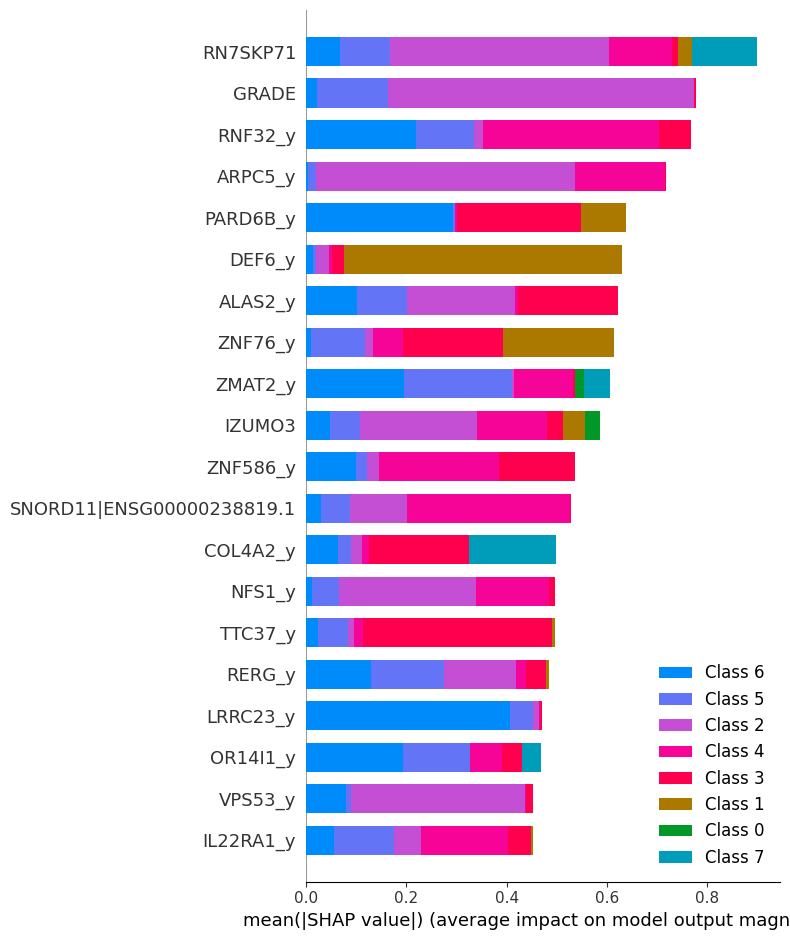

In [65]:
import shap

# Create TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values on validation set
shap_values = explainer.shap_values(X_val)

# Summary plot (all classes)
shap.summary_plot(shap_values, X_val, plot_type="bar")


In [66]:
X_val_top100 = X_val[top_features[:100]]  # assuming top_features is sorted by MI score
shap_values_top100 = explainer.shap_values(X_val_top100)
shap.summary_plot(shap_values_top100, X_val_top100, plot_type="bar")


XGBoostError: [22:04:57] C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api_utils.h:129: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (35552 vs. 176704) : 

In [67]:
# Select top 100 features based on previous MI scores
top_100_features = X_final.drop(columns="CLINICAL_STAGE").columns[:100]  # adjust X_final as needed

X_val_top100 = X_val[top_100_features]

# Use the same TreeExplainer
shap_values_top100 = explainer.shap_values(X_val_top100)

# Summary plot
shap.summary_plot(shap_values_top100, X_val_top100, plot_type="bar")


XGBoostError: [22:05:58] C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api_utils.h:129: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (35552 vs. 176704) : 

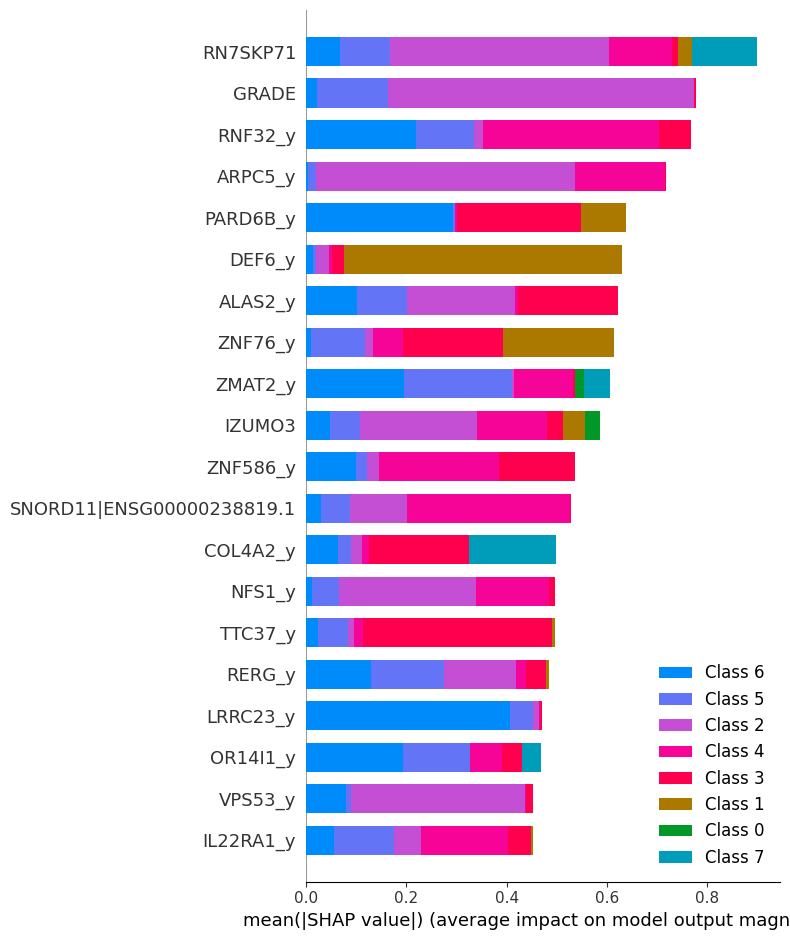

In [68]:
shap_values = explainer.shap_values(X_val)  # use all features model saw
shap.summary_plot(shap_values, X_val, plot_type="bar")


In [69]:
stage_map = {
    'Stage IC': 'I',
    'Stage IIA': 'II',
    'Stage IIB': 'II',
    'Stage IIC': 'II',
    'Stage IIIA': 'III',
    'Stage IIIB': 'III',
    'Stage IIIC': 'III',
    'Stage IV': 'IV'
}

y_collapsed = y.map(stage_map)


In [70]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_collapsed)
# Classes order: le.classes_


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_final.drop(columns=['CLINICAL_STAGE']),
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Collapse stages
stage_map = {
    'Stage IC': 'I',
    'Stage IIA': 'II',
    'Stage IIB': 'II',
    'Stage IIC': 'II',
    'Stage IIIA': 'III',
    'Stage IIIB': 'III',
    'Stage IIIC': 'III',
    'Stage IV': 'IV'
}

y_collapsed = X_final['CLINICAL_STAGE'].map(stage_map)

# Remove samples where the stage is missing (NaN) after mapping
mask = y_collapsed.notna()
X_filtered = X_final.loc[mask].drop(columns=['CLINICAL_STAGE'])
y_filtered = y_collapsed[mask]

# Remove any class with < 2 samples
counts = y_filtered.value_counts()
valid_classes = counts[counts >= 2].index
mask_valid = y_filtered.isin(valid_classes)
X_filtered = X_filtered.loc[mask_valid]
y_filtered = y_filtered.loc[mask_valid]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)

# Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (210, 501) (210,)
Validation shape: (45, 501) (45,)
Test shape: (46, 501) (46,)


In [73]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------- 1️⃣ Handle categorical columns -----------------
# Convert 'GRADE' to numeric (if present)
if 'GRADE' in X_train.columns:
    X_train['GRADE'] = X_train['GRADE'].astype('category').cat.codes
    X_val['GRADE'] = X_val['GRADE'].astype('category').cat.codes
    X_test['GRADE'] = X_test['GRADE'].astype('category').cat.codes

# ----------------- 2️⃣ Train XGBoost -----------------
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# ----------------- 3️⃣ Evaluate -----------------
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


[0]	validation_0-mlogloss:0.81334
[1]	validation_0-mlogloss:0.79481
[2]	validation_0-mlogloss:0.78276
[3]	validation_0-mlogloss:0.77076
[4]	validation_0-mlogloss:0.75914
[5]	validation_0-mlogloss:0.74969
[6]	validation_0-mlogloss:0.74123
[7]	validation_0-mlogloss:0.73139
[8]	validation_0-mlogloss:0.72365
[9]	validation_0-mlogloss:0.71522
[10]	validation_0-mlogloss:0.70748
[11]	validation_0-mlogloss:0.70064
[12]	validation_0-mlogloss:0.69472
[13]	validation_0-mlogloss:0.68656
[14]	validation_0-mlogloss:0.68044
[15]	validation_0-mlogloss:0.67636
[16]	validation_0-mlogloss:0.66995
[17]	validation_0-mlogloss:0.66650
[18]	validation_0-mlogloss:0.66449
[19]	validation_0-mlogloss:0.65656
[20]	validation_0-mlogloss:0.65601
[21]	validation_0-mlogloss:0.64803
[22]	validation_0-mlogloss:0.64587
[23]	validation_0-mlogloss:0.64503
[24]	validation_0-mlogloss:0.64306
[25]	validation_0-mlogloss:0.64392
[26]	validation_0-mlogloss:0.64401
[27]	validation_0-mlogloss:0.64398
[28]	validation_0-mlogloss:0.6

C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

In [74]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight= {class_imbalance_weights_here},  # OR use class_weight parameter for sklearn wrapper
    random_state=42,
    eval_metric='mlogloss'
)


NameError: name 'class_imbalance_weights_here' is not defined

In [75]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weights_dict = dict(zip(classes, class_weights))

# Assign a weight to each sample
sample_weights = np.array([weights_dict[label] for label in y_train])

# Train XGBoost with sample weights
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=True)


[0]	validation_0-mlogloss:1.07871
[1]	validation_0-mlogloss:1.06139
[2]	validation_0-mlogloss:1.04680
[3]	validation_0-mlogloss:1.03262
[4]	validation_0-mlogloss:1.02073
[5]	validation_0-mlogloss:1.00669
[6]	validation_0-mlogloss:0.99391
[7]	validation_0-mlogloss:0.98167
[8]	validation_0-mlogloss:0.96241
[9]	validation_0-mlogloss:0.94477
[10]	validation_0-mlogloss:0.93366
[11]	validation_0-mlogloss:0.92437
[12]	validation_0-mlogloss:0.91492
[13]	validation_0-mlogloss:0.90272
[14]	validation_0-mlogloss:0.89389
[15]	validation_0-mlogloss:0.88461
[16]	validation_0-mlogloss:0.87598
[17]	validation_0-mlogloss:0.86781
[18]	validation_0-mlogloss:0.86016
[19]	validation_0-mlogloss:0.85204
[20]	validation_0-mlogloss:0.84520
[21]	validation_0-mlogloss:0.83788
[22]	validation_0-mlogloss:0.82556
[23]	validation_0-mlogloss:0.81818
[24]	validation_0-mlogloss:0.81121
[25]	validation_0-mlogloss:0.79787
[26]	validation_0-mlogloss:0.79021
[27]	validation_0-mlogloss:0.78260
[28]	validation_0-mlogloss:0.7

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.8261

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.82      1.00      0.90        37
           2       1.00      0.17      0.29         6

    accuracy                           0.83        46
   macro avg       0.61      0.39      0.40        46
weighted avg       0.79      0.83      0.76        46

Confusion Matrix:
[[ 0  3  0]
 [ 0 37  0]
 [ 0  5  1]]


C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

In [77]:
# ------------------ Imports ------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
import catboost as cb

# ------------------ Prepare Data ------------------
# Assume X_final has your top 100 molecular features + AGE, GRADE, CLINICAL_STAGE
# Separate target
X = X_final.drop(columns=['CLINICAL_STAGE'])
y = X_final['CLINICAL_STAGE']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encode categorical features if any (e.g., GRADE)
if 'GRADE' in X.columns:
    X['GRADE'] = X['GRADE'].astype('category').cat.codes

# Split train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ------------------ Define Models ------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight="balanced"
    ),
    "LogisticRegression": LogisticRegression(
        multi_class="multinomial", max_iter=1000, class_weight="balanced"
    ),
    "SVM": SVC(class_weight="balanced", probability=True),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='mlogloss'
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=5, verbose=0, class_weights='Balanced'
    )
}

# ------------------ Train and Evaluate ------------------
for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


ModuleNotFoundError: No module named 'lightgbm'

In [78]:
pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [79]:
# ------------------ Imports ------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
import catboost as cb

# ------------------ Prepare Data ------------------
# Assume X_final has your top 100 molecular features + AGE, GRADE, CLINICAL_STAGE
# Separate target
X = X_final.drop(columns=['CLINICAL_STAGE'])
y = X_final['CLINICAL_STAGE']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encode categorical features if any (e.g., GRADE)
if 'GRADE' in X.columns:
    X['GRADE'] = X['GRADE'].astype('category').cat.codes

# Split train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ------------------ Define Models ------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight="balanced"
    ),
    "LogisticRegression": LogisticRegression(
        multi_class="multinomial", max_iter=1000, class_weight="balanced"
    ),
    "SVM": SVC(class_weight="balanced", probability=True),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='mlogloss'
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=5, verbose=0, class_weights='Balanced'
    )
}

# ------------------ Train and Evaluate ------------------
for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


ModuleNotFoundError: No module named 'catboost'

In [80]:
pip install catboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 437.5 kB/s eta 0:03:53
   ---------------------------------------- 0.5/102.4 MB 437.5 kB/s eta 0:03:53
   ---------------------------------------- 0.5/102.4 MB 437.5 kB/s eta 0:03:53
   ---------------------------------------- 0.8/102.4 MB 411.3 kB/s eta 0:04:08
   ---------------------------------------- 0.8/102.4 MB 411.3 kB/s eta 0:04:08
   ----------------------

In [81]:
# ------------------ Imports ------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
import catboost as cb

# ------------------ Prepare Data ------------------
# Assume X_final has your top 100 molecular features + AGE, GRADE, CLINICAL_STAGE
# Separate target
X = X_final.drop(columns=['CLINICAL_STAGE'])
y = X_final['CLINICAL_STAGE']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encode categorical features if any (e.g., GRADE)
if 'GRADE' in X.columns:
    X['GRADE'] = X['GRADE'].astype('category').cat.codes

# Split train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ------------------ Define Models ------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight="balanced"
    ),
    "LogisticRegression": LogisticRegression(
        multi_class="multinomial", max_iter=1000, class_weight="balanced"
    ),
    "SVM": SVC(class_weight="balanced", probability=True),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='mlogloss'
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=5, verbose=0, class_weights='Balanced'
    )
}

# ------------------ Train and Evaluate ------------------
for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Identify classes with fewer than 2 samples
value_counts = pd.Series(y_encoded).value_counts()
rare_classes = value_counts[value_counts < 2].index

# Filter out rare classes
mask = ~pd.Series(y_encoded).isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_encoded[mask]

# Now split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Identify classes with fewer than 2 samples
value_counts = pd.Series(y_encoded).value_counts()
rare_classes = value_counts[value_counts < 2].index

# Filter out rare classes
mask = ~pd.Series(y_encoded).isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_encoded[mask]

# Now split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assume X and y_encoded are ready
# 1️⃣ Remove rare classes first (any class with < 2 samples)
value_counts = pd.Series(y_encoded).value_counts()
rare_classes = value_counts[value_counts < 2].index

mask = ~pd.Series(y_encoded).isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_encoded[mask]

print("After removing rare classes:", X_filtered.shape, y_filtered.shape)

# 2️⃣ Now split 70/15/15 with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


After removing rare classes: (303, 501) (303,)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# -------------------- 1️⃣ Simplify stages --------------------
# Assume X_final has the 'CLINICAL_STAGE' column
X = X_final.drop(columns=['CLINICAL_STAGE'])
y = X_final['CLINICAL_STAGE']

# Map stages into I, II, III, IV
stage_map = {
    'Stage IA': 'I', 'Stage IB': 'I', 'Stage IC': 'I',
    'Stage IIA': 'II', 'Stage IIB': 'II', 'Stage IIC': 'II',
    'Stage IIIA': 'III', 'Stage IIIB': 'III', 'Stage IIIC': 'III',
    'Stage IV': 'IV'
}
y_mapped = y.map(stage_map)

# Remove any samples that did not match (e.g., '[Not Available]')
mask = y_mapped.notnull()
X = X[mask]
y_mapped = y_mapped[mask]

print("Shape after mapping stages:", X.shape, y_mapped.shape)

# -------------------- 2️⃣ Encode labels --------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y_mapped)

# -------------------- 3️⃣ Remove rare classes --------------------
value_counts = pd.Series(y_encoded).value_counts()
rare_classes = value_counts[value_counts < 2].index
mask = ~pd.Series(y_encoded).isin(rare_classes)
X_filtered = X[mask]
y_filtered = y_encoded[mask]

print("After removing rare classes:", X_filtered.shape, y_filtered.shape)

# -------------------- 4️⃣ Train/Validation/Test split --------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Shape after mapping stages: (302, 501) (302,)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_380\2250963316.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_filtered = X[mask]


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# -------------------- 1️⃣ Simplify stages --------------------
X = X_final.drop(columns=['CLINICAL_STAGE'])
y = X_final['CLINICAL_STAGE']

# Map stages into I, II, III, IV
stage_map = {
    'Stage IA': 'I', 'Stage IB': 'I', 'Stage IC': 'I',
    'Stage IIA': 'II', 'Stage IIB': 'II', 'Stage IIC': 'II',
    'Stage IIIA': 'III', 'Stage IIIB': 'III', 'Stage IIIC': 'III',
    'Stage IV': 'IV'
}
y_mapped = y.map(stage_map)

# Remove rows with unmapped stages
mask_valid = y_mapped.notnull()
X = X[mask_valid].reset_index(drop=True)
y_mapped = y_mapped[mask_valid].reset_index(drop=True)

# -------------------- 2️⃣ Encode labels --------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y_mapped)

# -------------------- 3️⃣ Remove rare classes --------------------
value_counts = pd.Series(y_encoded).value_counts()
rare_classes = value_counts[value_counts < 2].index

# Make sure we filter using a Series aligned with X
mask = pd.Series(y_encoded).isin(rare_classes) == False
X_filtered = X[mask].reset_index(drop=True)
y_filtered = pd.Series(y_encoded)[mask].reset_index(drop=True)

print("After removing rare classes:", X_filtered.shape, y_filtered.shape)

# -------------------- 4️⃣ Train/Validation/Test split --------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


After removing rare classes: (301, 501) (301,)
Train: (210, 501) (210,)
Validation: (45, 501) (45,)
Test: (46, 501) (46,)


In [87]:
# -------------------- 1️⃣ Import libraries --------------------
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------- 2️⃣ Prepare categorical columns --------------------
# Convert 'GRADE' to numeric if it's categorical
for df in [X_train, X_val, X_test]:
    if 'GRADE' in df.columns:
        df['GRADE'] = df['GRADE'].astype('category').cat.codes

# -------------------- 3️⃣ Define models --------------------
models = {
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        random_state=42, eval_metric='mlogloss'
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=10, random_state=42
    )
}

# -------------------- 4️⃣ Train and evaluate --------------------
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Train
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)] if name=="XGBoost" else None, verbose=False)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



===== XGBoost =====


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [1 2 3]

In [88]:
from sklearn.preprocessing import LabelEncoder

# Encode y_train, y_val, y_test starting from 0
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded   = le.transform(y_val)
y_test_encoded  = le.transform(y_test)

# Now train XGBoost safely
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    random_state=42, eval_metric='mlogloss'
)

xgb.fit(
    X_train, y_train_encoded,
    eval_set=[(X_val, y_val_encoded)],
    verbose=False
)

# Predict
y_pred = xgb.predict(X_test)


In [89]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    random_state=42, eval_metric='mlogloss'
)

xgb.fit(X_train, y_train_encoded, eval_set=[(X_val, y_val_encoded)], verbose=False)

y_pred = xgb.predict(X_test)

print("XGBoost Test Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))


XGBoost Test Accuracy: 0.8043478260869565
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.80      1.00      0.89        37
           2       0.00      0.00      0.00         6

    accuracy                           0.80        46
   macro avg       0.27      0.33      0.30        46
weighted avg       0.65      0.80      0.72        46

Confusion Matrix:
 [[ 0  3  0]
 [ 0 37  0]
 [ 0  6  0]]


C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

In [90]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42
)

lgb_model.fit(X_train, y_train_encoded, eval_set=[(X_val, y_val_encoded)], verbose=False)

y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM Test Accuracy:", accuracy_score(y_test_encoded, y_pred_lgb))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_lgb))


TypeError: LGBMClassifier.fit() got an unexpected keyword argument 'verbose'

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train_encoded)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Test Accuracy:", accuracy_score(y_test_encoded, y_pred_rf))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_rf))


NameError: name 'X_train' is not defined

In [7]:
# Identify categorical/object columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Convert to category codes for LightGBM
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_val[col] = X_val[col].astype('category').cat.codes
    X_test[col] = X_test[col].astype('category').cat.codes


NameError: name 'X_train' is not defined

In [93]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42
)

lgb_model.fit(X_train, y_train_encoded, eval_set=[(X_val, y_val_encoded)], verbose=False)

y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM Test Accuracy:", accuracy_score(y_test_encoded, y_pred_lgb))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_lgb))


TypeError: LGBMClassifier.fit() got an unexpected keyword argument 'verbose'

In [6]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ensure categorical columns are numeric codes
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_val[col] = X_val[col].astype('category').cat.codes
    X_test[col] = X_test[col].astype('category').cat.codes

# Initialize LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train (LightGBM ignores verbose here)
lgb_model.fit(
    X_train,
    y_train_encoded,
    eval_set=[(X_val, y_val_encoded)],
    eval_metric='multi_logloss'
)

# Predict
y_pred_lgb = lgb_model.predict(X_test)

# Metrics
print("LightGBM Test Accuracy:", accuracy_score(y_test_encoded, y_pred_lgb))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_lgb))


NameError: name 'X_train' is not defined

In [96]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 1.3/332.0 MB 4.2 MB/s eta 0:01:19
   ---------------------------------------- 2.4/332.0 MB 4.5 MB/s eta 0:01:13
   ---------------------------------------- 3.4/332.0 MB 4.7 MB/s eta 0:01:10
    --------------------------------------- 4.5/332.0 MB 4.7 MB/s eta 0:01:10
    --------------------------------------- 5.5/332.0 MB 4.6 MB/s eta 0:01:11
    --------------------------------------- 6.6/332.0 MB 4.8 MB/s eta 0:01:08
    --------------------------------------- 7.3/332.0 MB 4.8 MB/s eta 0:01:08
   - -------------------------------------- 8.4/332.0 MB 4.6 MB/s eta 0:01:10
   - -------------------------------------- 9.4/332.0 MB 4.7 MB/s eta 0:01:10
   - -------

In [3]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# --------------------------------------------
# 1. Separate clinical & molecular features
# --------------------------------------------

clinical_features = ["AGE", "GRADE"]  # keep these always
molecular_features = [col for col in X.columns if col not in clinical_features]

# --------------------------------------------
# 2. Compute Mutual Information (MI) for molecular features
# --------------------------------------------

mi_scores = mutual_info_classif(X[molecular_features], y, random_state=42)

mi_df = pd.DataFrame({
    "feature": molecular_features,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False)

# --------------------------------------------
# 3. Pick Top 100 Molecular Features
# --------------------------------------------

top_100_genes = mi_df.head(100)["feature"].tolist()

print("Top 100 selected molecular features:")
print(top_100_genes)

# --------------------------------------------
# 4. Create Final Feature Set (100 genes + clinical)
# --------------------------------------------

final_features = top_100_genes + clinical_features

X_reduced = X[final_features]

print("Reduced Feature Shape:", X_reduced.shape)


NameError: name 'X' is not defined

In [4]:
df = cleaned_df.copy()   # or whatever your dataframe variable is


NameError: name 'cleaned_df' is not defined

In [5]:
dir()


['In',
 'Out',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'clinical_features',
 'clinical_patient',
 'clinical_sample',
 'exit',
 'get_ipython',
 'mutual_info_classif',
 'np',
 'open',
 'pd',
 'quit']